# Spaceship Titanic ? Machine Learning Classification

**Competition:** [Kaggle Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic)  
**Objective:** predict whether each passenger was transported to an alternate dimension after the anomaly.

This notebook documents the full analytical journey: data understanding, exploratory analysis, statistical hypothesis testing, feature engineering, preprocessing, model comparison, and submission generation.


## 1. Imports and configuration

The libraries below support data preparation, visualization, statistical inference, and machine-learning experiments. Plot defaults are configured once so every figure is readable and consistent throughout the analysis.


In [515]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from plottable import Table
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact
import itertools
import statsmodels.stats.multitest as smm
from sklearn.preprocessing import OneHotEncoder
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

DATA_DIR = Path('../data')
RANDOM_STATE = 42
N_SPLITS = 5


## 2. Project and dataset overview

The dataset combines passenger demographics, journey details, cabin location, and onboard spending. `Transported` is the binary training target; the test set has the same predictors without this label. The data dictionary below provides the context used to interpret later EDA and feature-engineering decisions.

### Variables

| Feature | Description |
|---|---|
| `PassengerId` | Passenger group and within-group identifier |
| `HomePlanet` / `Destination` | Journey origin and destination |
| `CryoSleep` / `VIP` | Passenger service-status indicators |
| `Cabin` | Deck, cabin number, and side |
| `Age` and spending columns | Demographic and onboard-behaviour signals |
| `Transported` | Target: whether the passenger was transported |


## 3. Data loading

Load the training, test, and submission-template files. Displaying representative rows verifies schema alignment before any transformation is applied.


In [516]:
df_train = pd.read_csv(DATA_DIR / "train.csv")
df_test = pd.read_csv(DATA_DIR / "test.csv")
df_sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")


In [517]:
print(f'Train: {df_train.shape} | Test: {df_test.shape}')
display(df_train.head())
display(df_train.isna().sum().sort_values(ascending=False).to_frame('missing'))

Train: (8693, 14) | Test: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


,missing
CryoSleep,217
ShoppingMall,208
VIP,203
HomePlanet,201
Name,200
Cabin,199
VRDeck,188
Spa,183
FoodCourt,183
Destination,182


## 4. Data overview and initial structural preparation

The next cells inspect data types, descriptive statistics, duplicates, and missingness. Cabin and passenger-group fields are parsed first because their components are needed for the cabin-location analysis that follows. This is structural preparation, not a change to the modelling hypothesis.


In [518]:
df_train['GroupID'] = df_train['PassengerId'].str.split('_', expand=True).get(0)

In [519]:
display(df_train.isna().sum().sort_values(ascending=False).to_frame('missing'))

,missing
CryoSleep,217
ShoppingMall,208
VIP,203
HomePlanet,201
Name,200
Cabin,199
VRDeck,188
Spa,183
FoodCourt,183
Destination,182


In [520]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

# CryoSleep = True → fill NaN with 0
df_train.loc[df_train["CryoSleep"] == True, spend_cols] = (
    df_train.loc[df_train["CryoSleep"] == True, spend_cols].fillna(0)
)

# CryoSleep = False → fill NaN with the column mean
df_train.loc[df_train["CryoSleep"] == False, spend_cols] = (
    df_train.loc[df_train["CryoSleep"] == False, spend_cols]
      .fillna(df_train.loc[df_train["CryoSleep"] == False, spend_cols].mean())
)

In [521]:
df_train["TotalSpent"] = df_train[spend_cols].sum(axis=1)

In [522]:
df_train.loc[df_train['CryoSleep'].isna() & (df_train["TotalSpent"] == 0), "CryoSleep"] = True
df_train.loc[df_train['CryoSleep'].isna() & (df_train["TotalSpent"] > 0), "CryoSleep"] = False

In [523]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].mean())

In [524]:
df_train["HomePlanet"] = (
    df_train.groupby("GroupID")["HomePlanet"]
    .transform(lambda x: x.ffill().bfill())
)

C:\Users\Reza.M\AppData\Local\Temp\ipykernel_5864\3778952555.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.ffill().bfill())


In [525]:
df_train["Cabin"] = (
    df_train.groupby("GroupID")["Cabin"]
    .transform(lambda x: x.ffill().bfill())
)

C:\Users\Reza.M\AppData\Local\Temp\ipykernel_5864\3715225023.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.ffill().bfill())


In [526]:
df_train["Destination"] = (
    df_train.groupby("GroupID")["Destination"]
    .transform(lambda x: x.ffill().bfill())
)

C:\Users\Reza.M\AppData\Local\Temp\ipykernel_5864\3746210962.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.ffill().bfill())


In [527]:
df_train[['P1_Cabin', 'P2_Cabin' , 'P3_Cabin']] = df_train['Cabin'].str.split('/', expand=True)

In [528]:
display(df_train.isna().sum().sort_values(ascending=False).to_frame('missing'))

,missing
VIP,203
Name,200
HomePlanet,111
Destination,103
P2_Cabin,99
P1_Cabin,99
Cabin,99
P3_Cabin,99
ShoppingMall,8
VRDeck,7


In [529]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8582 non-null   object 
 2   CryoSleep     8693 non-null   object 
 3   Cabin         8594 non-null   object 
 4   Destination   8590 non-null   object 
 5   Age           8693 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8691 non-null   float64
 8   FoodCourt     8690 non-null   float64
 9   ShoppingMall  8685 non-null   float64
 10  Spa           8688 non-null   float64
 11  VRDeck        8686 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
 14  GroupID       8693 non-null   object 
 15  TotalSpent    8693 non-null   float64
 16  P1_Cabin      8594 non-null   object 
 17  P2_Cabin      8594 non-null   object 
 18  P3_Cabin      8594 non-null 

In [530]:
df_train.describe(include = 'all')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,GroupID,TotalSpent,P1_Cabin,P2_Cabin,P3_Cabin
count,8693,8582,8693,8594,8590,8693.000000,8490,8691.000000,8690.000000,8685.000000,8688.000000,8686.000000,8493,8693,8693,8693.000000,8594,8594,8594
unique,8693,3,2,6560,3,NaN,2,NaN,NaN,NaN,NaN,NaN,8473,2,6217,NaN,8,1817,2
top,9280_02,Earth,False,G/734/S,TRAPPIST-1e,NaN,False,NaN,NaN,NaN,NaN,NaN,Anton Woody,True,8168,NaN,F,82,S
freq,1,4634,5558,8,5967,NaN,8291,NaN,NaN,NaN,NaN,NaN,2,4378,8,NaN,2808,28,4343
mean,NaN,NaN,NaN,NaN,NaN,28.827930,NaN,224.531963,457.614209,172.968681,311.086499,305.019597,NaN,NaN,NaN,1470.427642,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,14.339054,NaN,660.266821,1595.497920,598.065063,1125.498275,1134.184557,NaN,NaN,NaN,2807.500095,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,20.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,734.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,37.000000,NaN,60.500000,93.000000,32.000000,74.000000,58.000000,NaN,NaN,NaN,1500.000000,NaN,NaN,NaN


## 5. Exploratory data analysis

Numerical distributions, outliers, normality diagnostics, and target-separated views are examined to understand how passenger characteristics relate to transportation. These visual findings motivate the non-parametric tests and later model features.


### Visual exploration

The following reusable plots make numerical distributions, departures from normality, and class-specific patterns directly comparable across the passenger-spending and age variables.

In [531]:
def analysis_numeric_col(data, col):
    fig, axes = plt.subplots(3, 3, figsize=(20, 15))
    colors = ["#9ECAD6", "#ADE792"]

    # ---- without Transported ----
    
    # boxplot
    sns.boxplot(data[col], color="#9ECAD6", ax=axes[0, 0])
    axes[0, 0].set_title(f"Boxplot of {col}")

    # hisplot
    sns.histplot(data[col], kde=True, color="#9ECAD6", ax=axes[0, 1])
    axes[0, 1].set_title(f"Histogram of {col}")

    # qqplot
    stats.probplot(data[col], dist="norm", plot=axes[0, 2])
    line = axes[0, 2].get_lines()[1]
    points = axes[0, 2].get_lines()[0]
    line.set_color("#ADE792")
    points.set_color("#9ECAD6")
    axes[0, 2].set_title(f"QQ-plot of {col}")


    # ---- with Transported ----
    
    # boxplot
    sns.boxplot(x=data["Transported"], y=data[col], color="#9ECAD6", ax=axes[1, 0])
    axes[1, 0].set_title(f"Boxplot of {col} by Transported")

    # hisplot
    sns.histplot(x=data[col], hue=data["Transported"], multiple="stack", palette=["#9ECAD6", "#ADE792"], ax=axes[1, 1])
    axes[1, 1].set_title(f"Histogram of {col} by Transported")

    # qqplot 
    color_map = {0: "#9ECAD6", 1: "#ADE792"}
    groups = sorted(data["Transported"].unique())
    for each in groups:
        res = stats.probplot(data.loc[data["Transported"] == each, col], dist="norm")
        axes[1, 2].plot(res[0][0], res[0][1], "o", color=color_map[each], label=each)
        axes[1, 2].plot(res[0][0], res[1][0]*res[0][0] + res[1][1], color=color_map[each])
        axes[1, 2].set_title(f"QQ-plot of {col} by Transported")
    axes[1, 2].legend(title="Transported", loc="best")

    # kdeplot
    sns.kdeplot(data, x=col, hue="Transported", fill=True, common_norm=False, palette=["#9ECAD6", "#ADE792"], ax=axes[2, 0])
    axes[2, 0].set_title(f"KDE of {col} by Transported")

    # # stacked bar 
    # cross_tab = pd.crosstab(data[col], data["Transported"])
    # cross_tab = cross_tab.div(cross_tab.sum(axis=1), axis=0)
    # cross_tab.plot(kind="bar", stacked=True, ax=axes[2, 1], color=colors)
    # axes[2, 1].set_ylim(0, 1)
    # axes[2, 1].set_title(f"Stacked Bar of {col} by Transported")

    axes[2, 2].remove()
    
    # stacked bar 2   
    if isinstance(data[col][0], float):
        binned = pd.cut(data[col], bins=8)
        ctab = pd.crosstab(binned, data['Transported'])
        ctab = ctab.div(ctab.sum(axis=1), axis=0)
        ctab.plot(kind="bar", stacked=True, ax=axes[2, 1], width=1.0, color=colors, edgecolor='black', legend=True)
        axes[2, 1].set_ylim(0, 1)
        axes[2, 1].set_title(f"Stacked Bar of {col} by Transported")
        axes[2, 1].tick_params(axis='x', rotation=0)
        new_labels = [f"{interval.left:.2f}" for interval in ctab.index]
        axes[2, 1].set_xticklabels(new_labels)
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
    else:
        binned = pd.cut(data[col], bins=8)
        ctab = pd.crosstab(binned, data['Transported'])
        ctab = ctab.div(ctab.sum(axis=1), axis=0)
        ctab.plot(kind="bar", stacked=True, ax=axes[2, 1], width=1.0, color=colors, edgecolor='black', legend=True)
        axes[2, 1].set_ylim(0, 1)
        axes[2, 1].set_title(f"Stacked Bar of {col} by Transported")
        axes[2, 1].tick_params(axis='x', rotation=0)
        new_labels = [f"{int(interval.left)}" for interval in ctab.index]
        axes[2, 1].set_xticklabels(new_labels)
        plt.xticks(rotation=90)
        
    plt.tight_layout()
    plt.show()

### 5.1 Numerical features and target relationship

For each numerical variable, the notebook uses distribution plots, QQ plots, and target-stratified visualizations. Because these variables can be skewed and contain outliers, the accompanying Mann?Whitney U test is appropriate for comparing the two target groups without assuming normality.


In [532]:
def mannwhitney_test(data, col):
    group0 = data[data['Transported'] == 0][col].dropna()
    group1 = data[data['Transported'] == 1][col].dropna()
    print(group0.shape)
    print(group1.shape)

    print(group0.head())
    print(group1.head())

    stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')

    print(f"\n{col} → p_value = {p_value:.4f}")

    # Interpretation
    if p_value > 0.05:
        print("✅ No significant difference → Fail to reject H₀")
    else:
        print("❌ Significant difference → Reject H₀")

C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarn

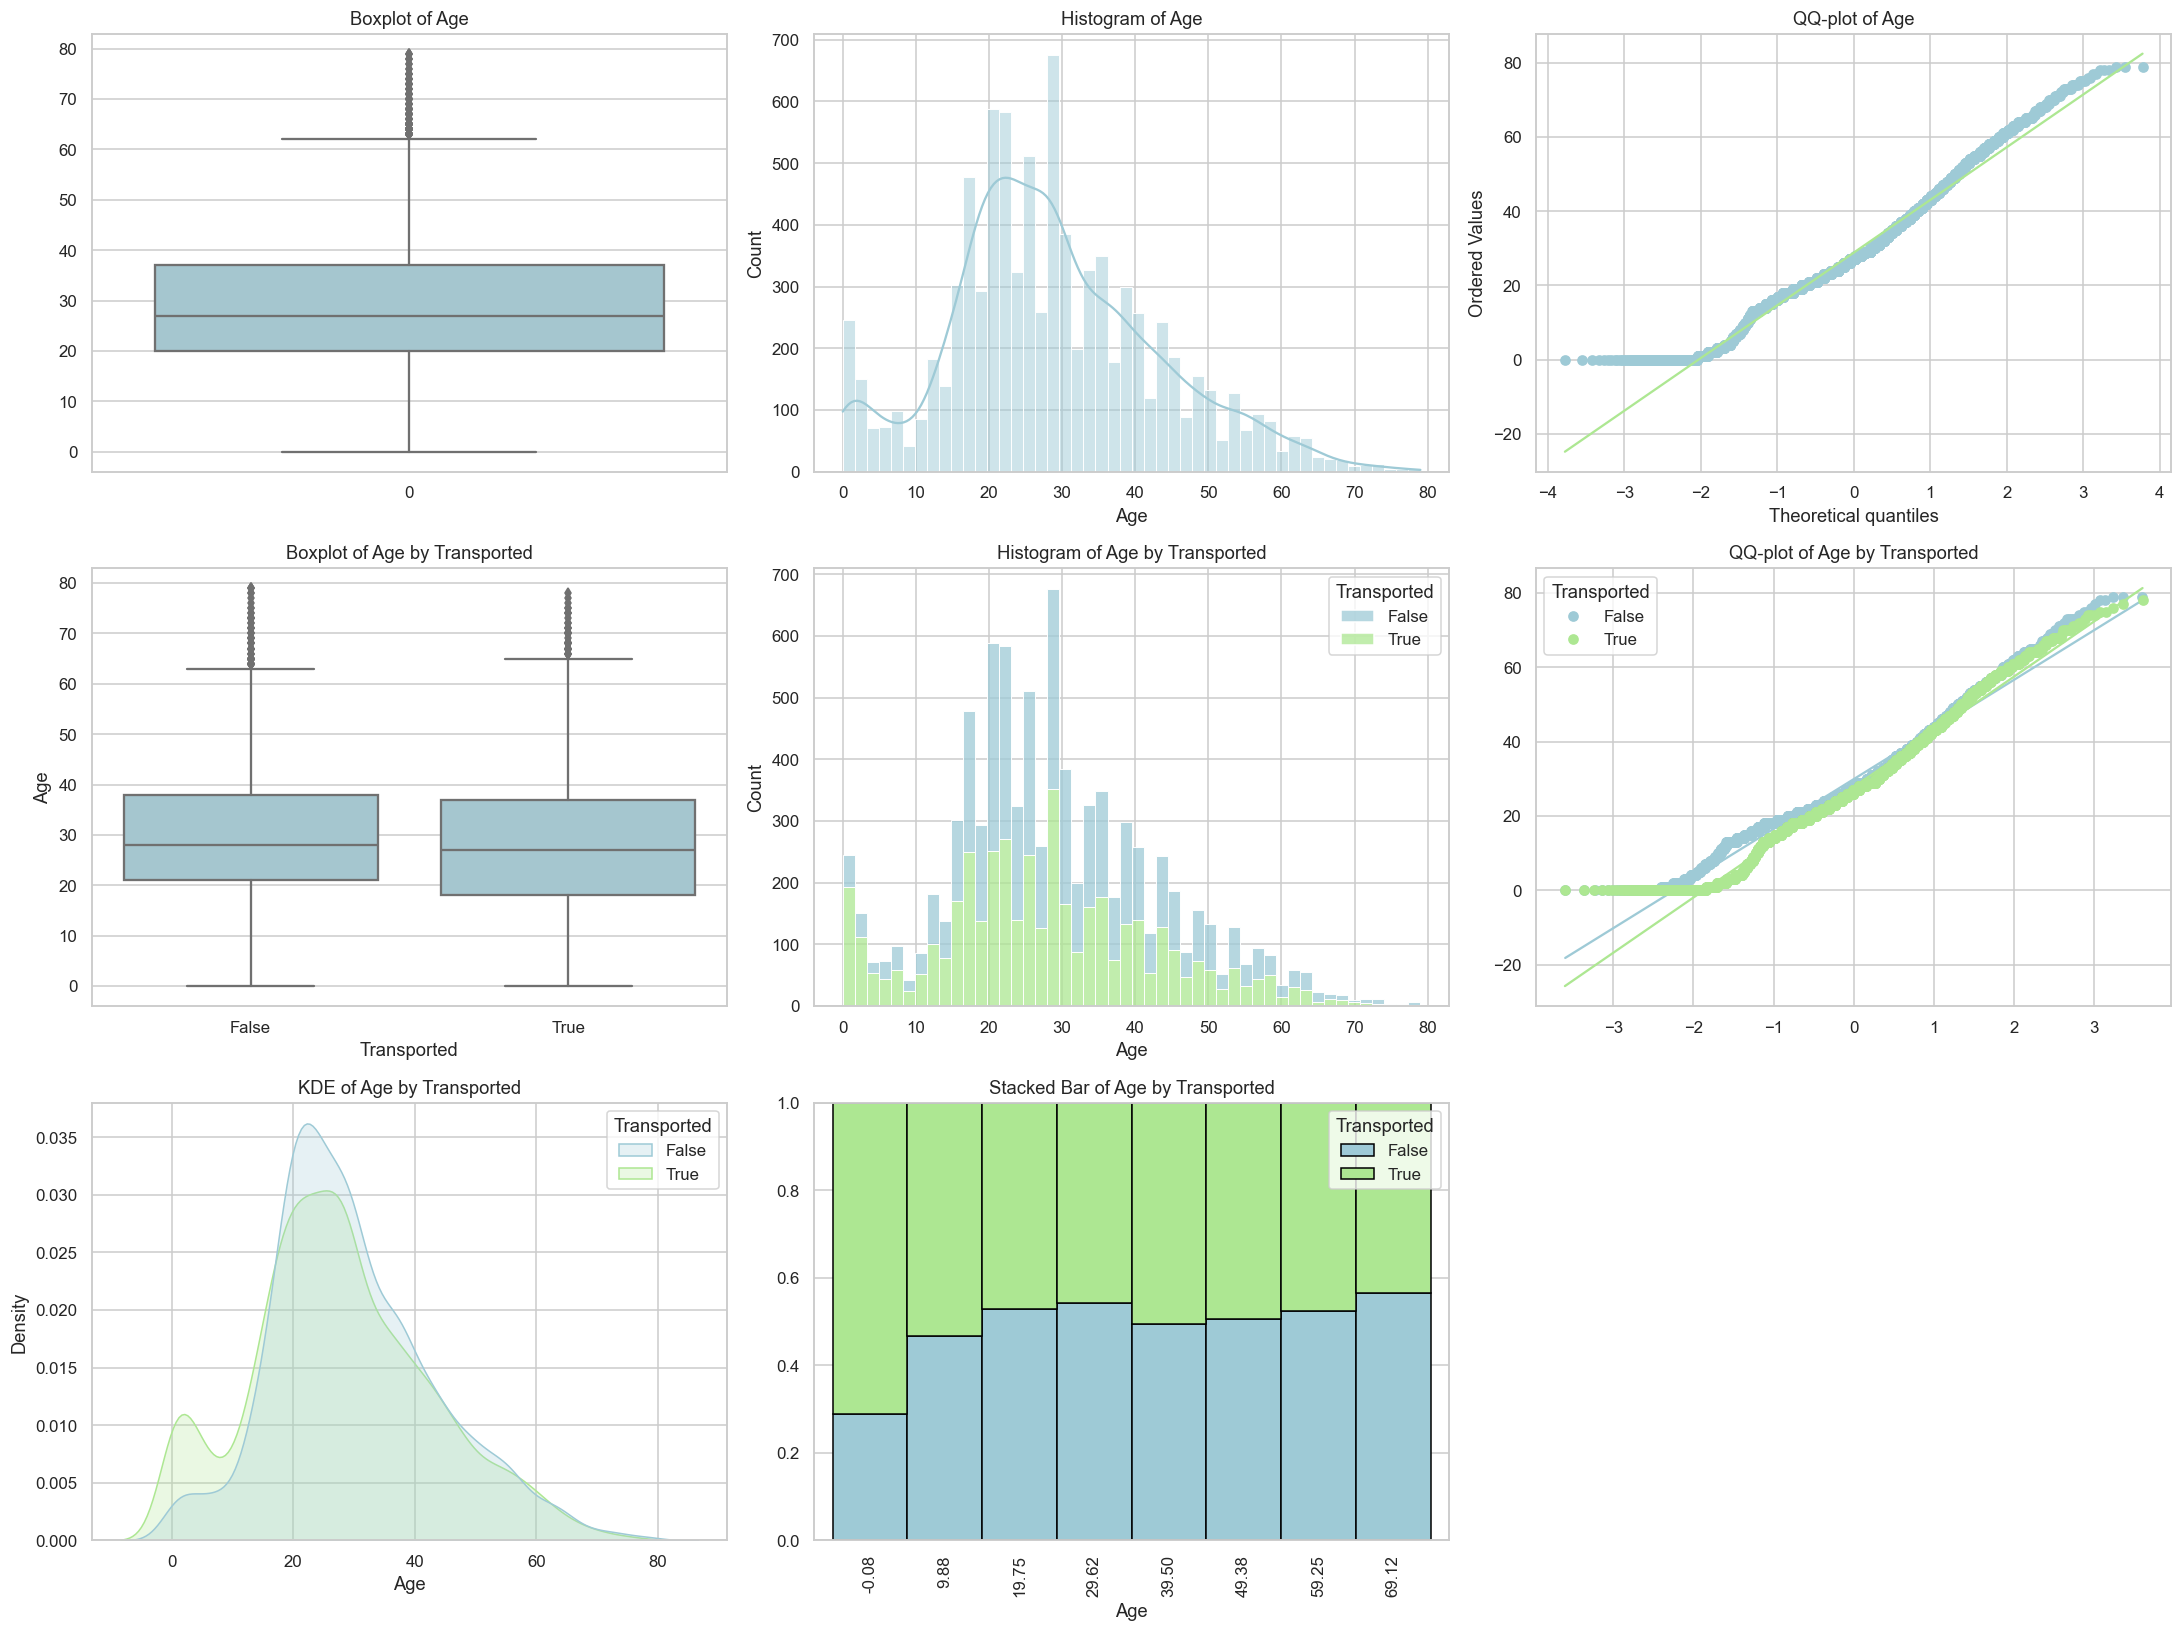

<Figure size 704x528 with 0 Axes>

(4315,)
(4378,)
0     39.0
2     58.0
3     33.0
13    48.0
15    31.0
Name: Age, dtype: float64
1    24.0
4    16.0
5    44.0
6    26.0
7    28.0
Name: Age, dtype: float64

Age → p_value = 0.0000
❌ Significant difference → Reject H₀


In [533]:
analysis_numeric_col(df_train,"Age")
mannwhitney_test(df_train,"Age")

C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarn

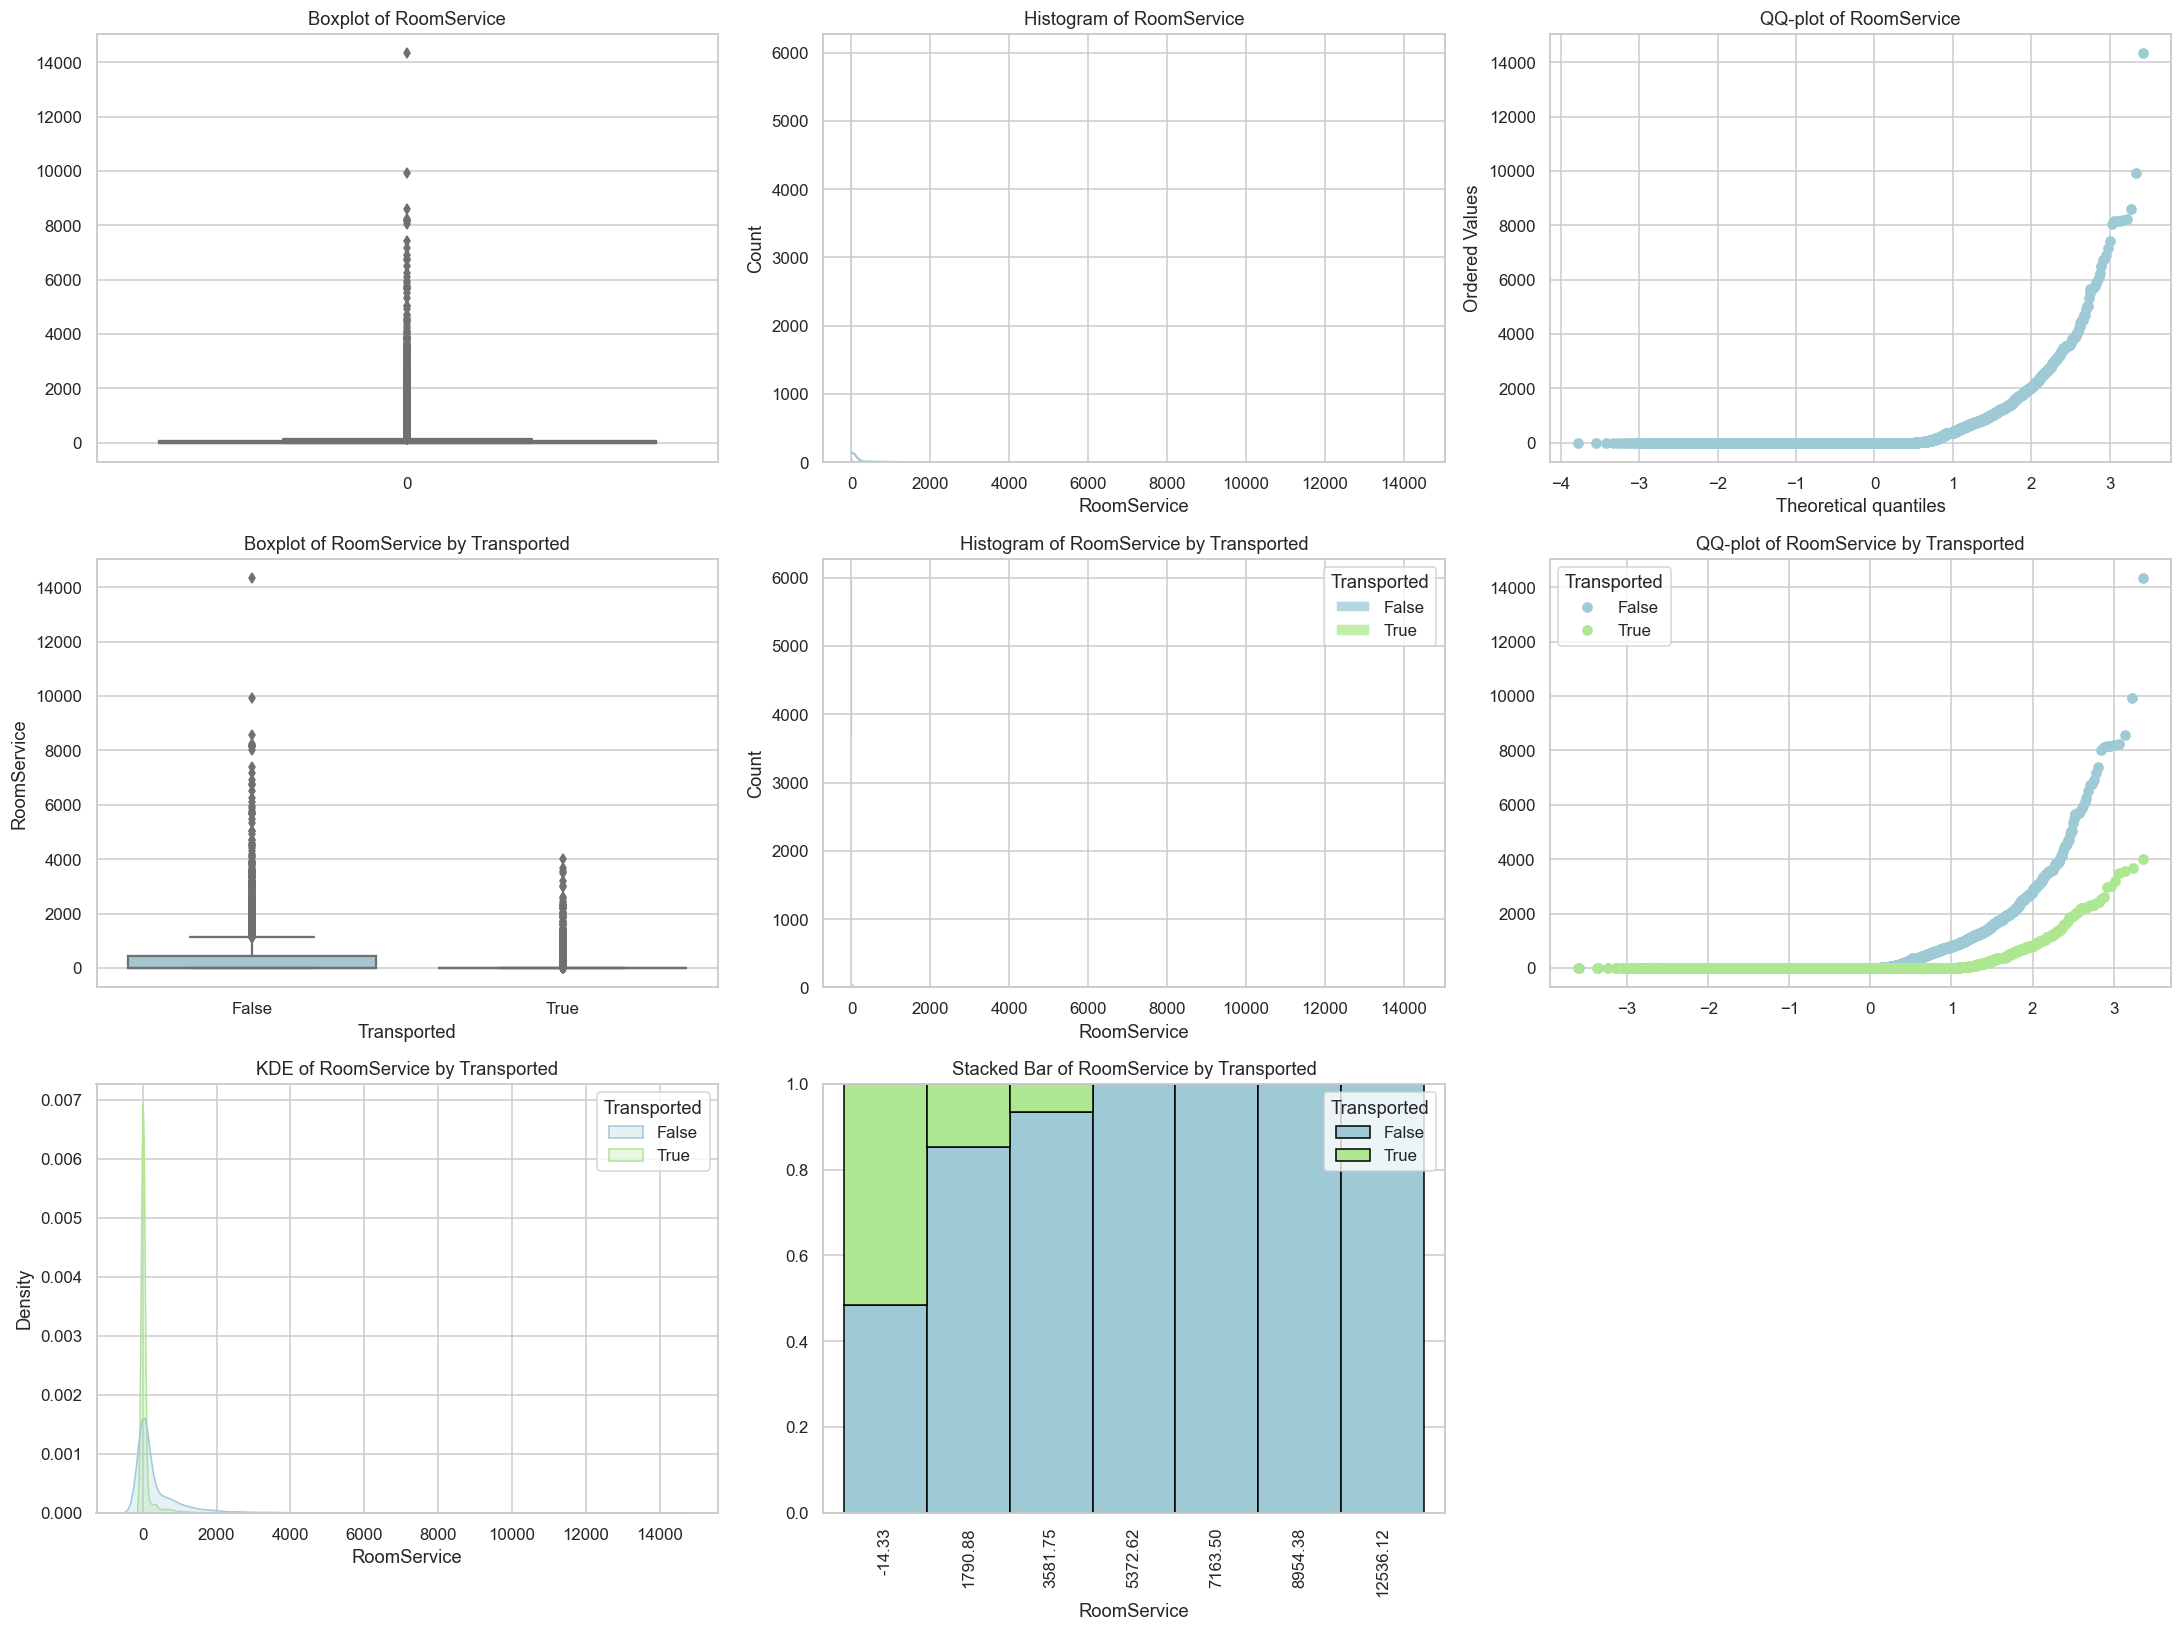

<Figure size 704x528 with 0 Axes>

(4314,)
(4377,)
0       0.0
2      43.0
3       0.0
13    719.0
15     32.0
Name: RoomService, dtype: float64
1    109.0
4    303.0
5      0.0
6     42.0
7      0.0
Name: RoomService, dtype: float64

RoomService → p_value = 0.0000
❌ Significant difference → Reject H₀


In [534]:
analysis_numeric_col(df_train,"RoomService")
mannwhitney_test(df_train,"RoomService")


C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarn

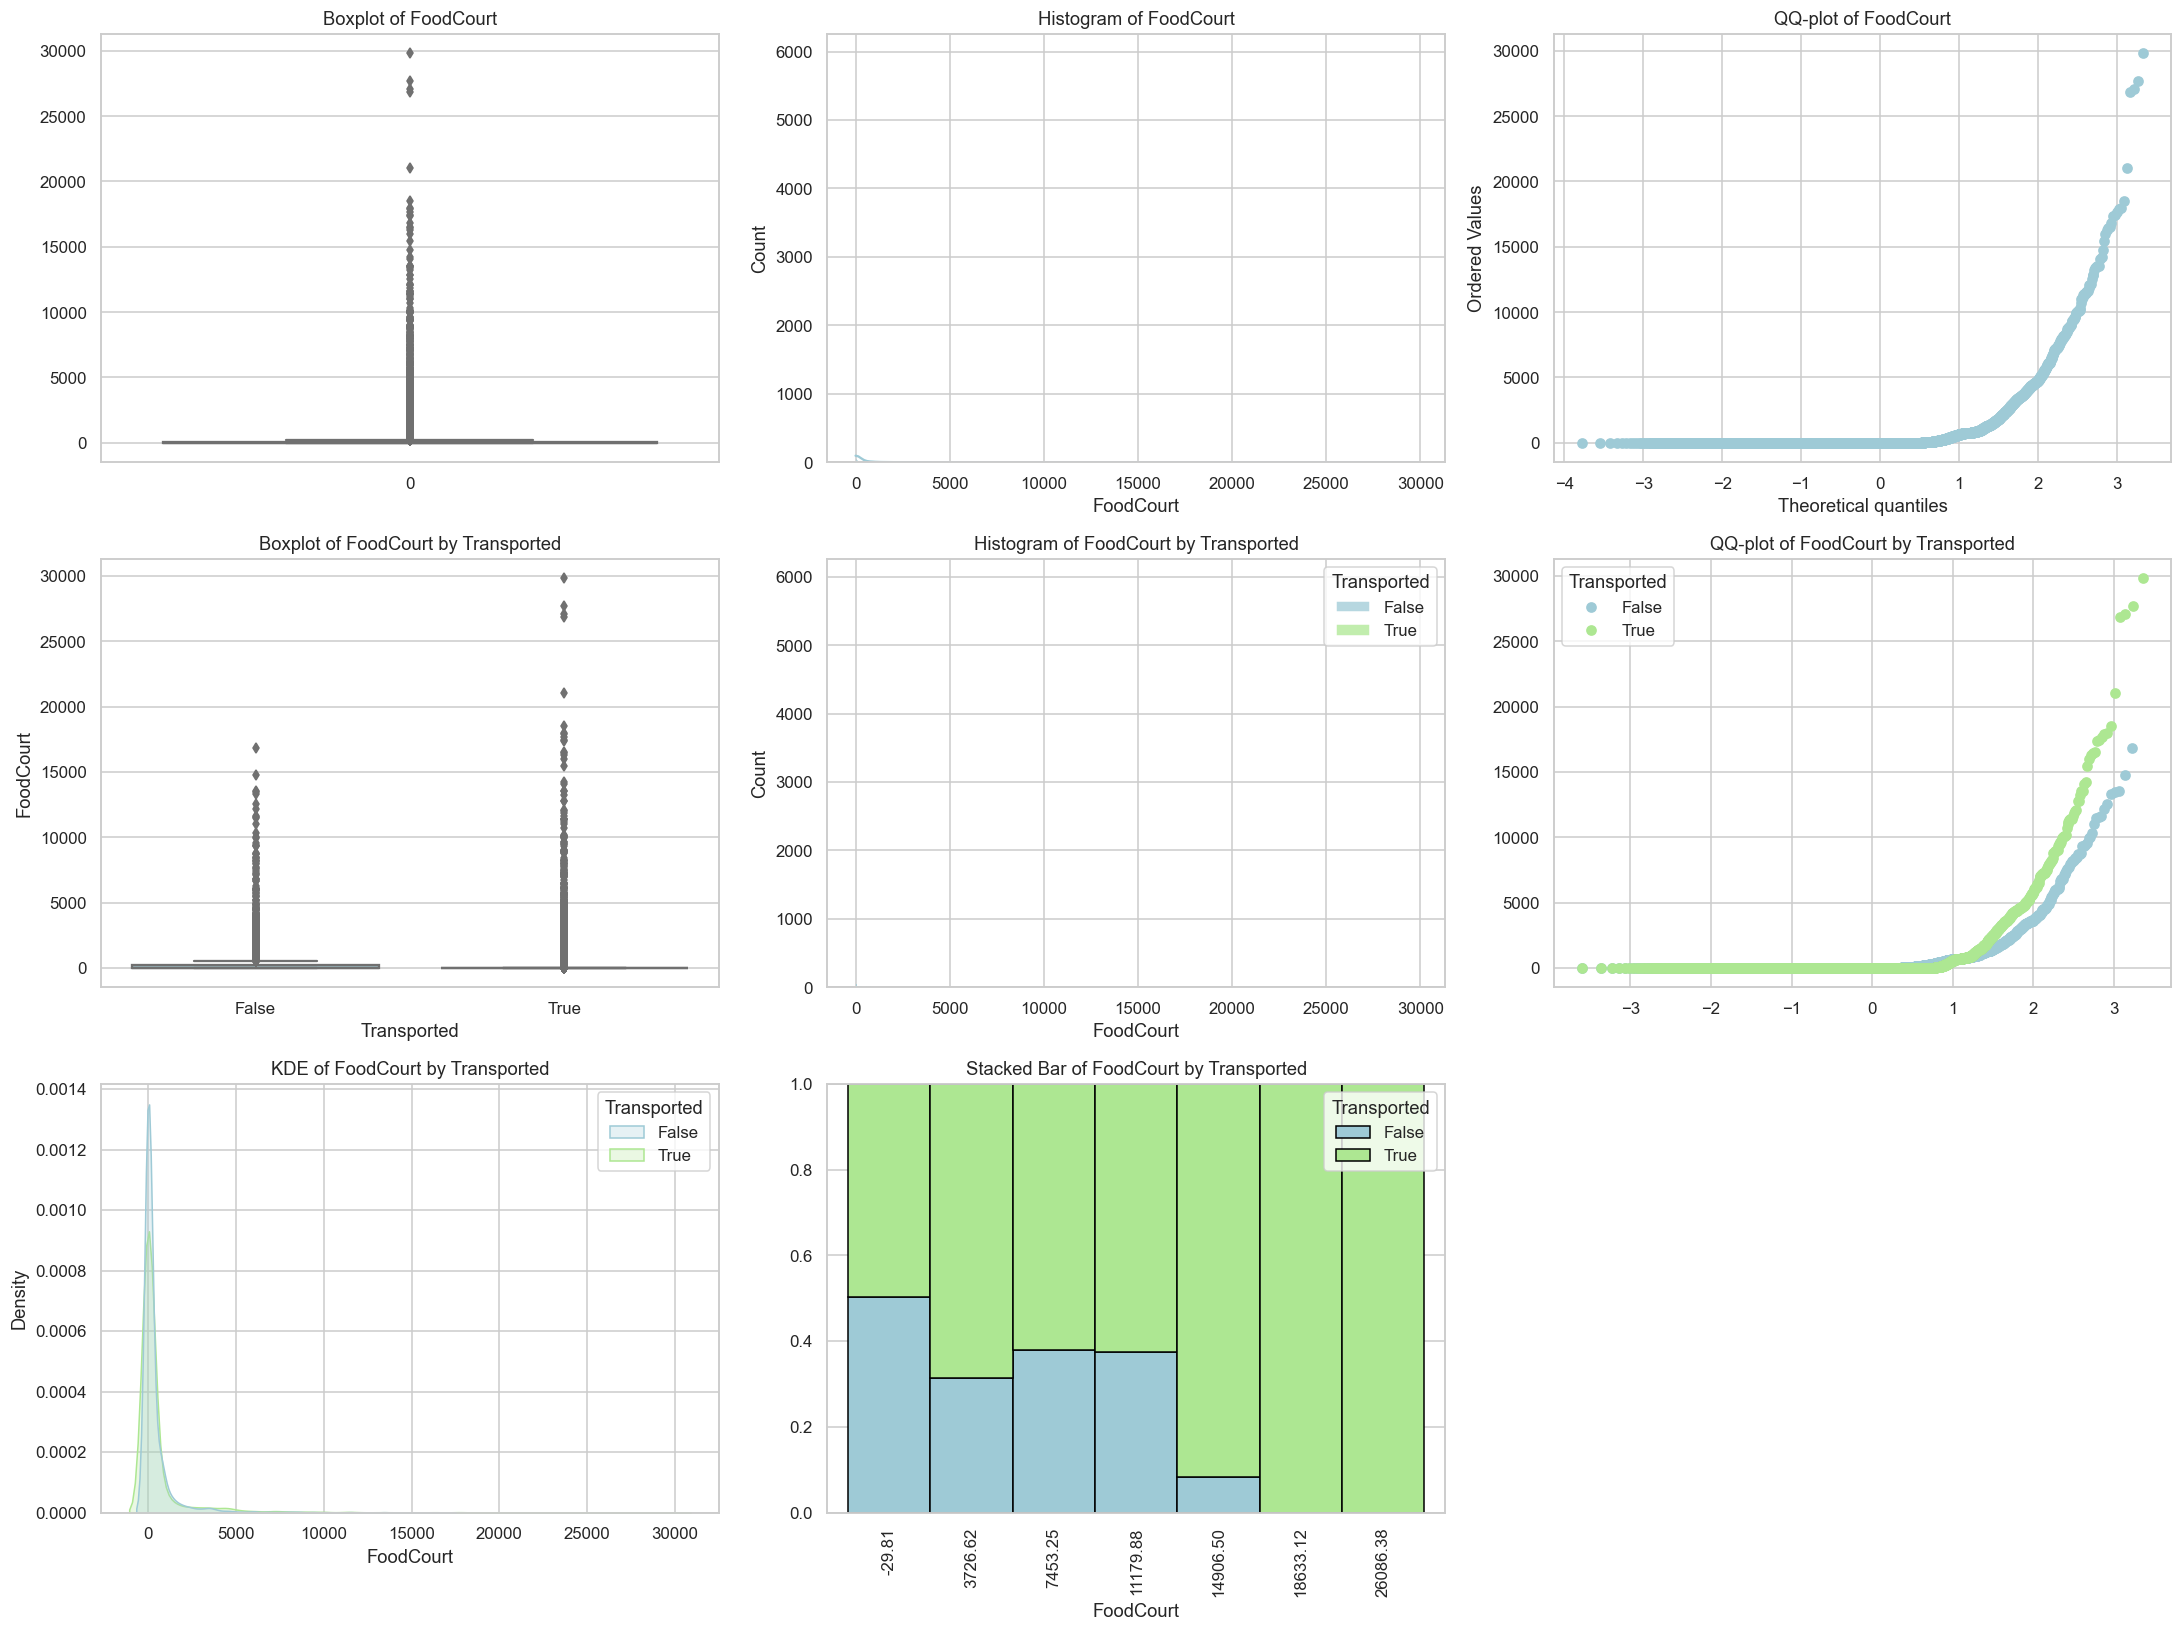

<Figure size 704x528 with 0 Axes>

(4313,)
(4377,)
0        0.0
2     3576.0
3     1283.0
13       1.0
15       0.0
Name: FoodCourt, dtype: float64
1       9.0
4      70.0
5     483.0
6    1539.0
7       0.0
Name: FoodCourt, dtype: float64

FoodCourt → p_value = 0.0000
❌ Significant difference → Reject H₀


In [535]:
analysis_numeric_col(df_train,"FoodCourt")
mannwhitney_test(df_train,"FoodCourt")

C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarn

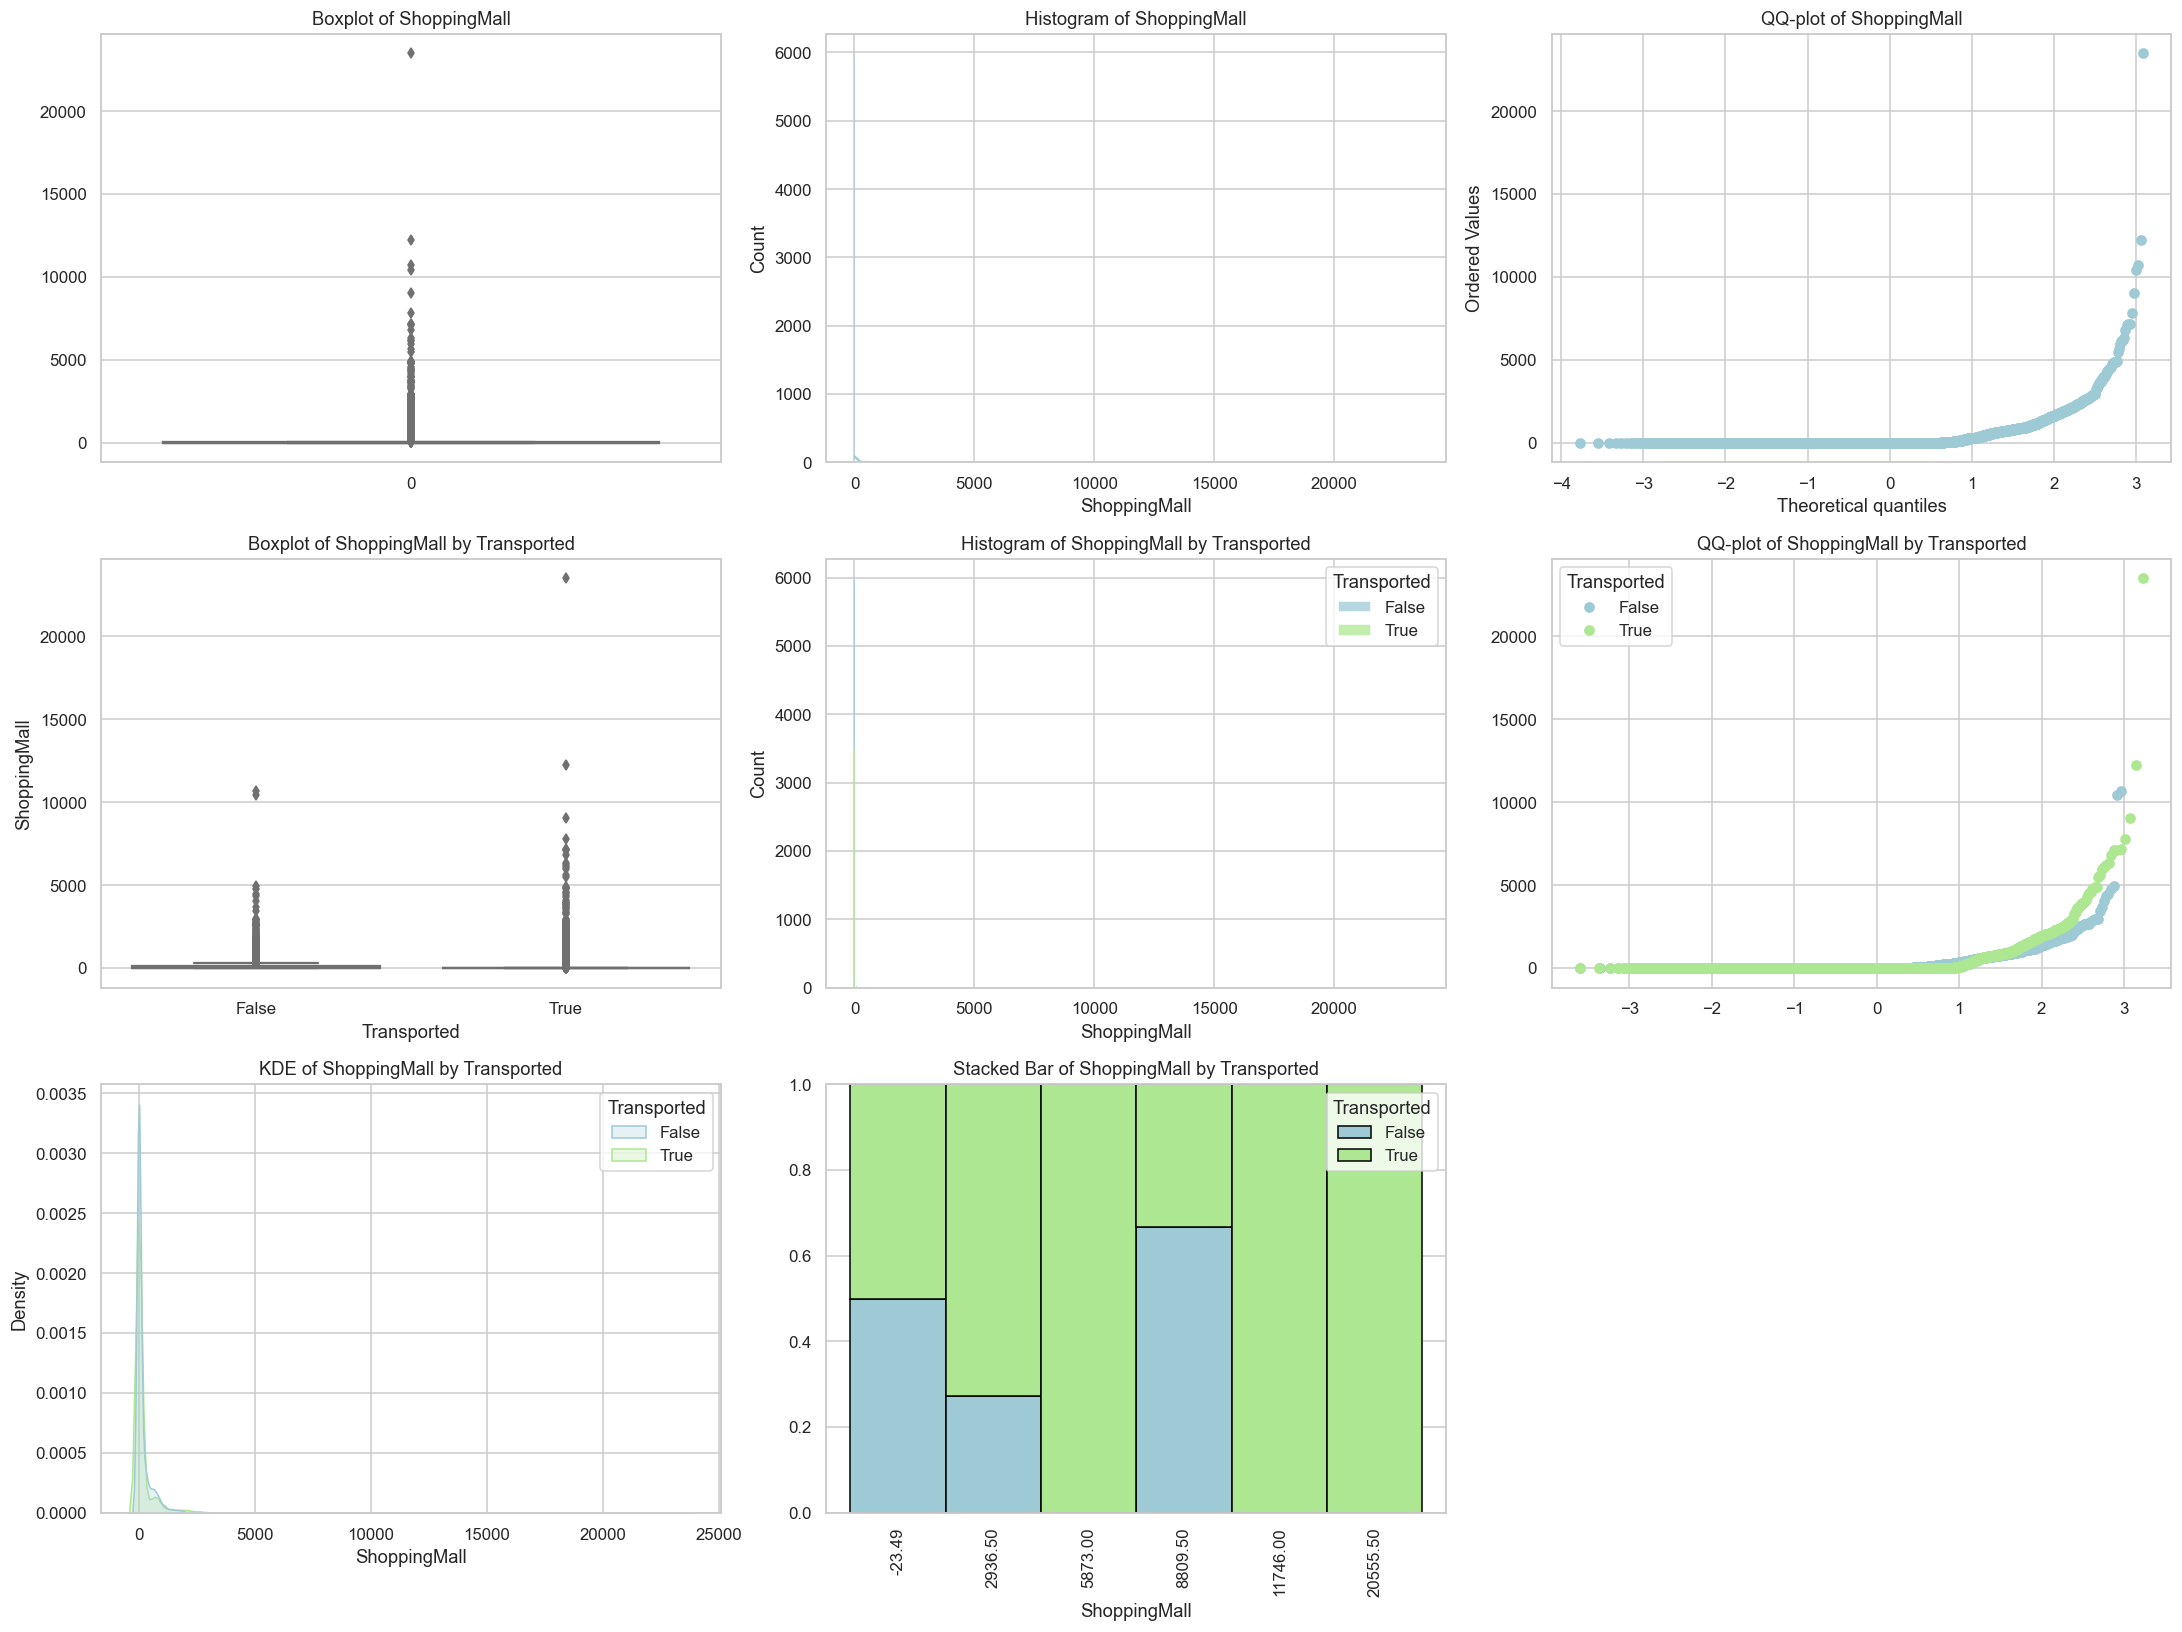

<Figure size 704x528 with 0 Axes>

(4309,)
(4376,)
0       0.0
2       0.0
3     371.0
13     65.0
15    876.0
Name: ShoppingMall, dtype: float64
1     25.0
4    151.0
5      0.0
6      3.0
7      0.0
Name: ShoppingMall, dtype: float64

ShoppingMall → p_value = 0.0000
❌ Significant difference → Reject H₀


In [536]:
analysis_numeric_col(df_train,"ShoppingMall")
mannwhitney_test(df_train,"ShoppingMall")

C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarn

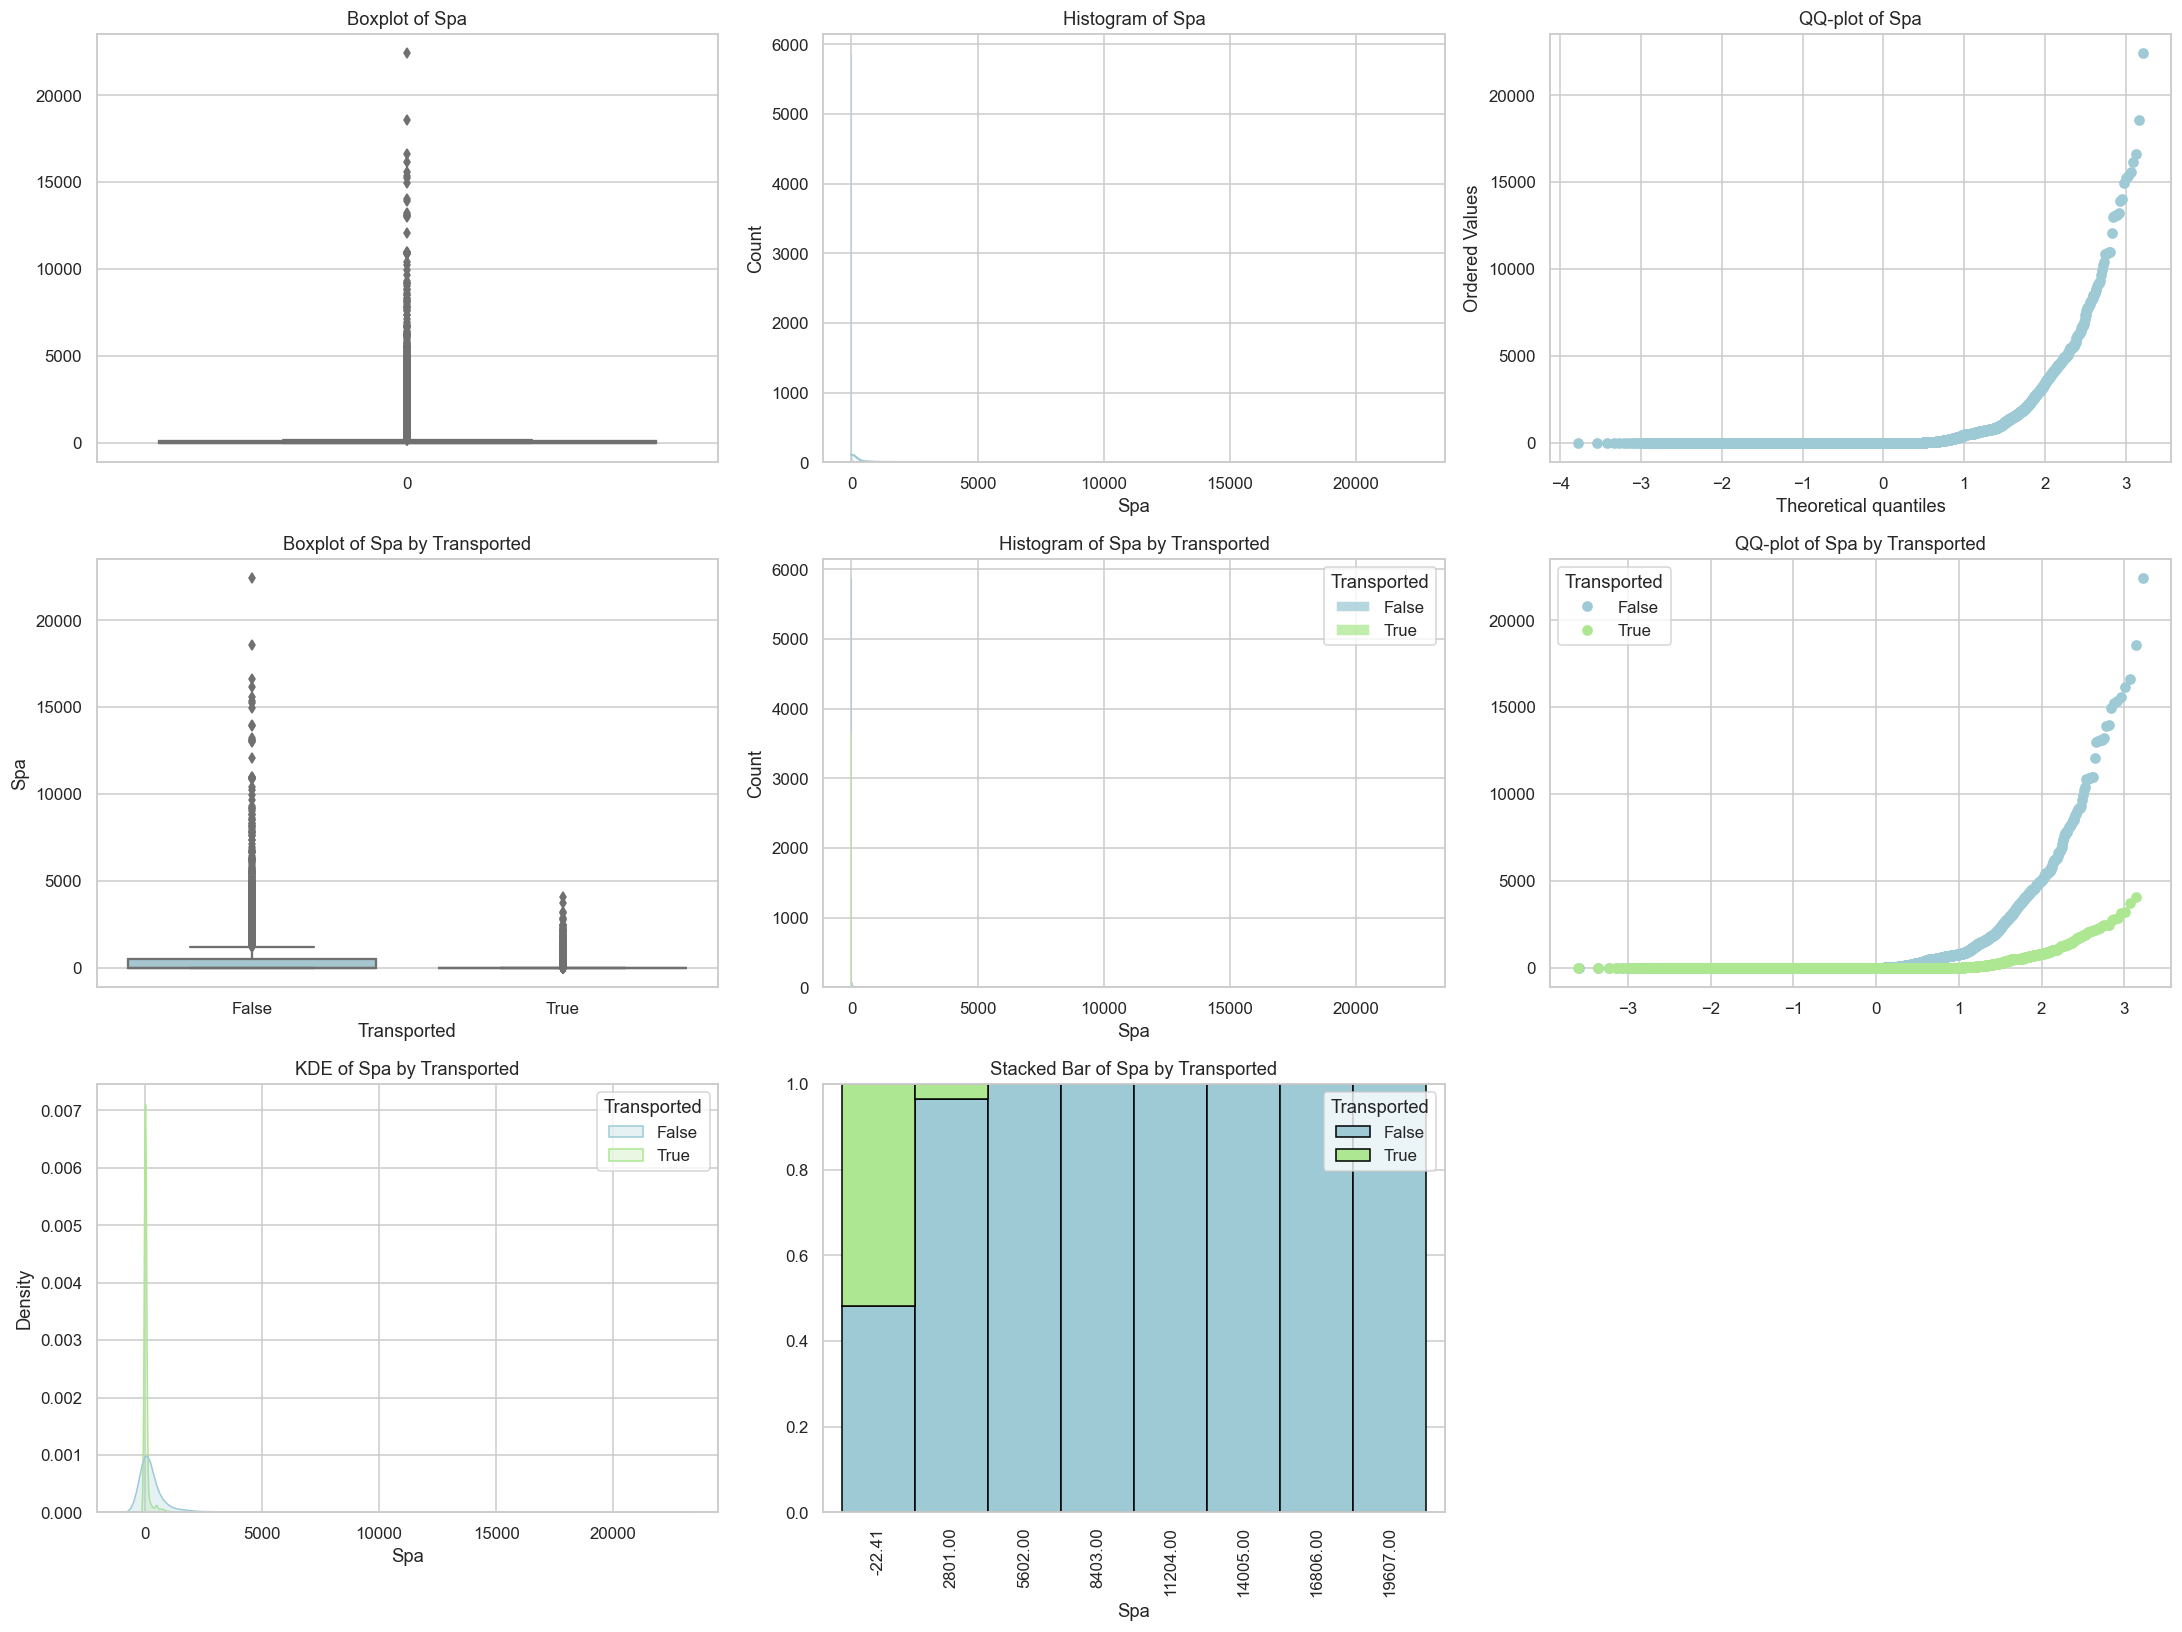

<Figure size 704x528 with 0 Axes>

(4313,)
(4375,)
0        0.0
2     6715.0
3     3329.0
13       0.0
15       0.0
Name: Spa, dtype: float64
1    549.0
4    565.0
5    291.0
6      0.0
7      0.0
Name: Spa, dtype: float64

Spa → p_value = 0.0000
❌ Significant difference → Reject H₀


In [537]:
analysis_numeric_col(df_train,"Spa")
mannwhitney_test(df_train,"Spa")

C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarn

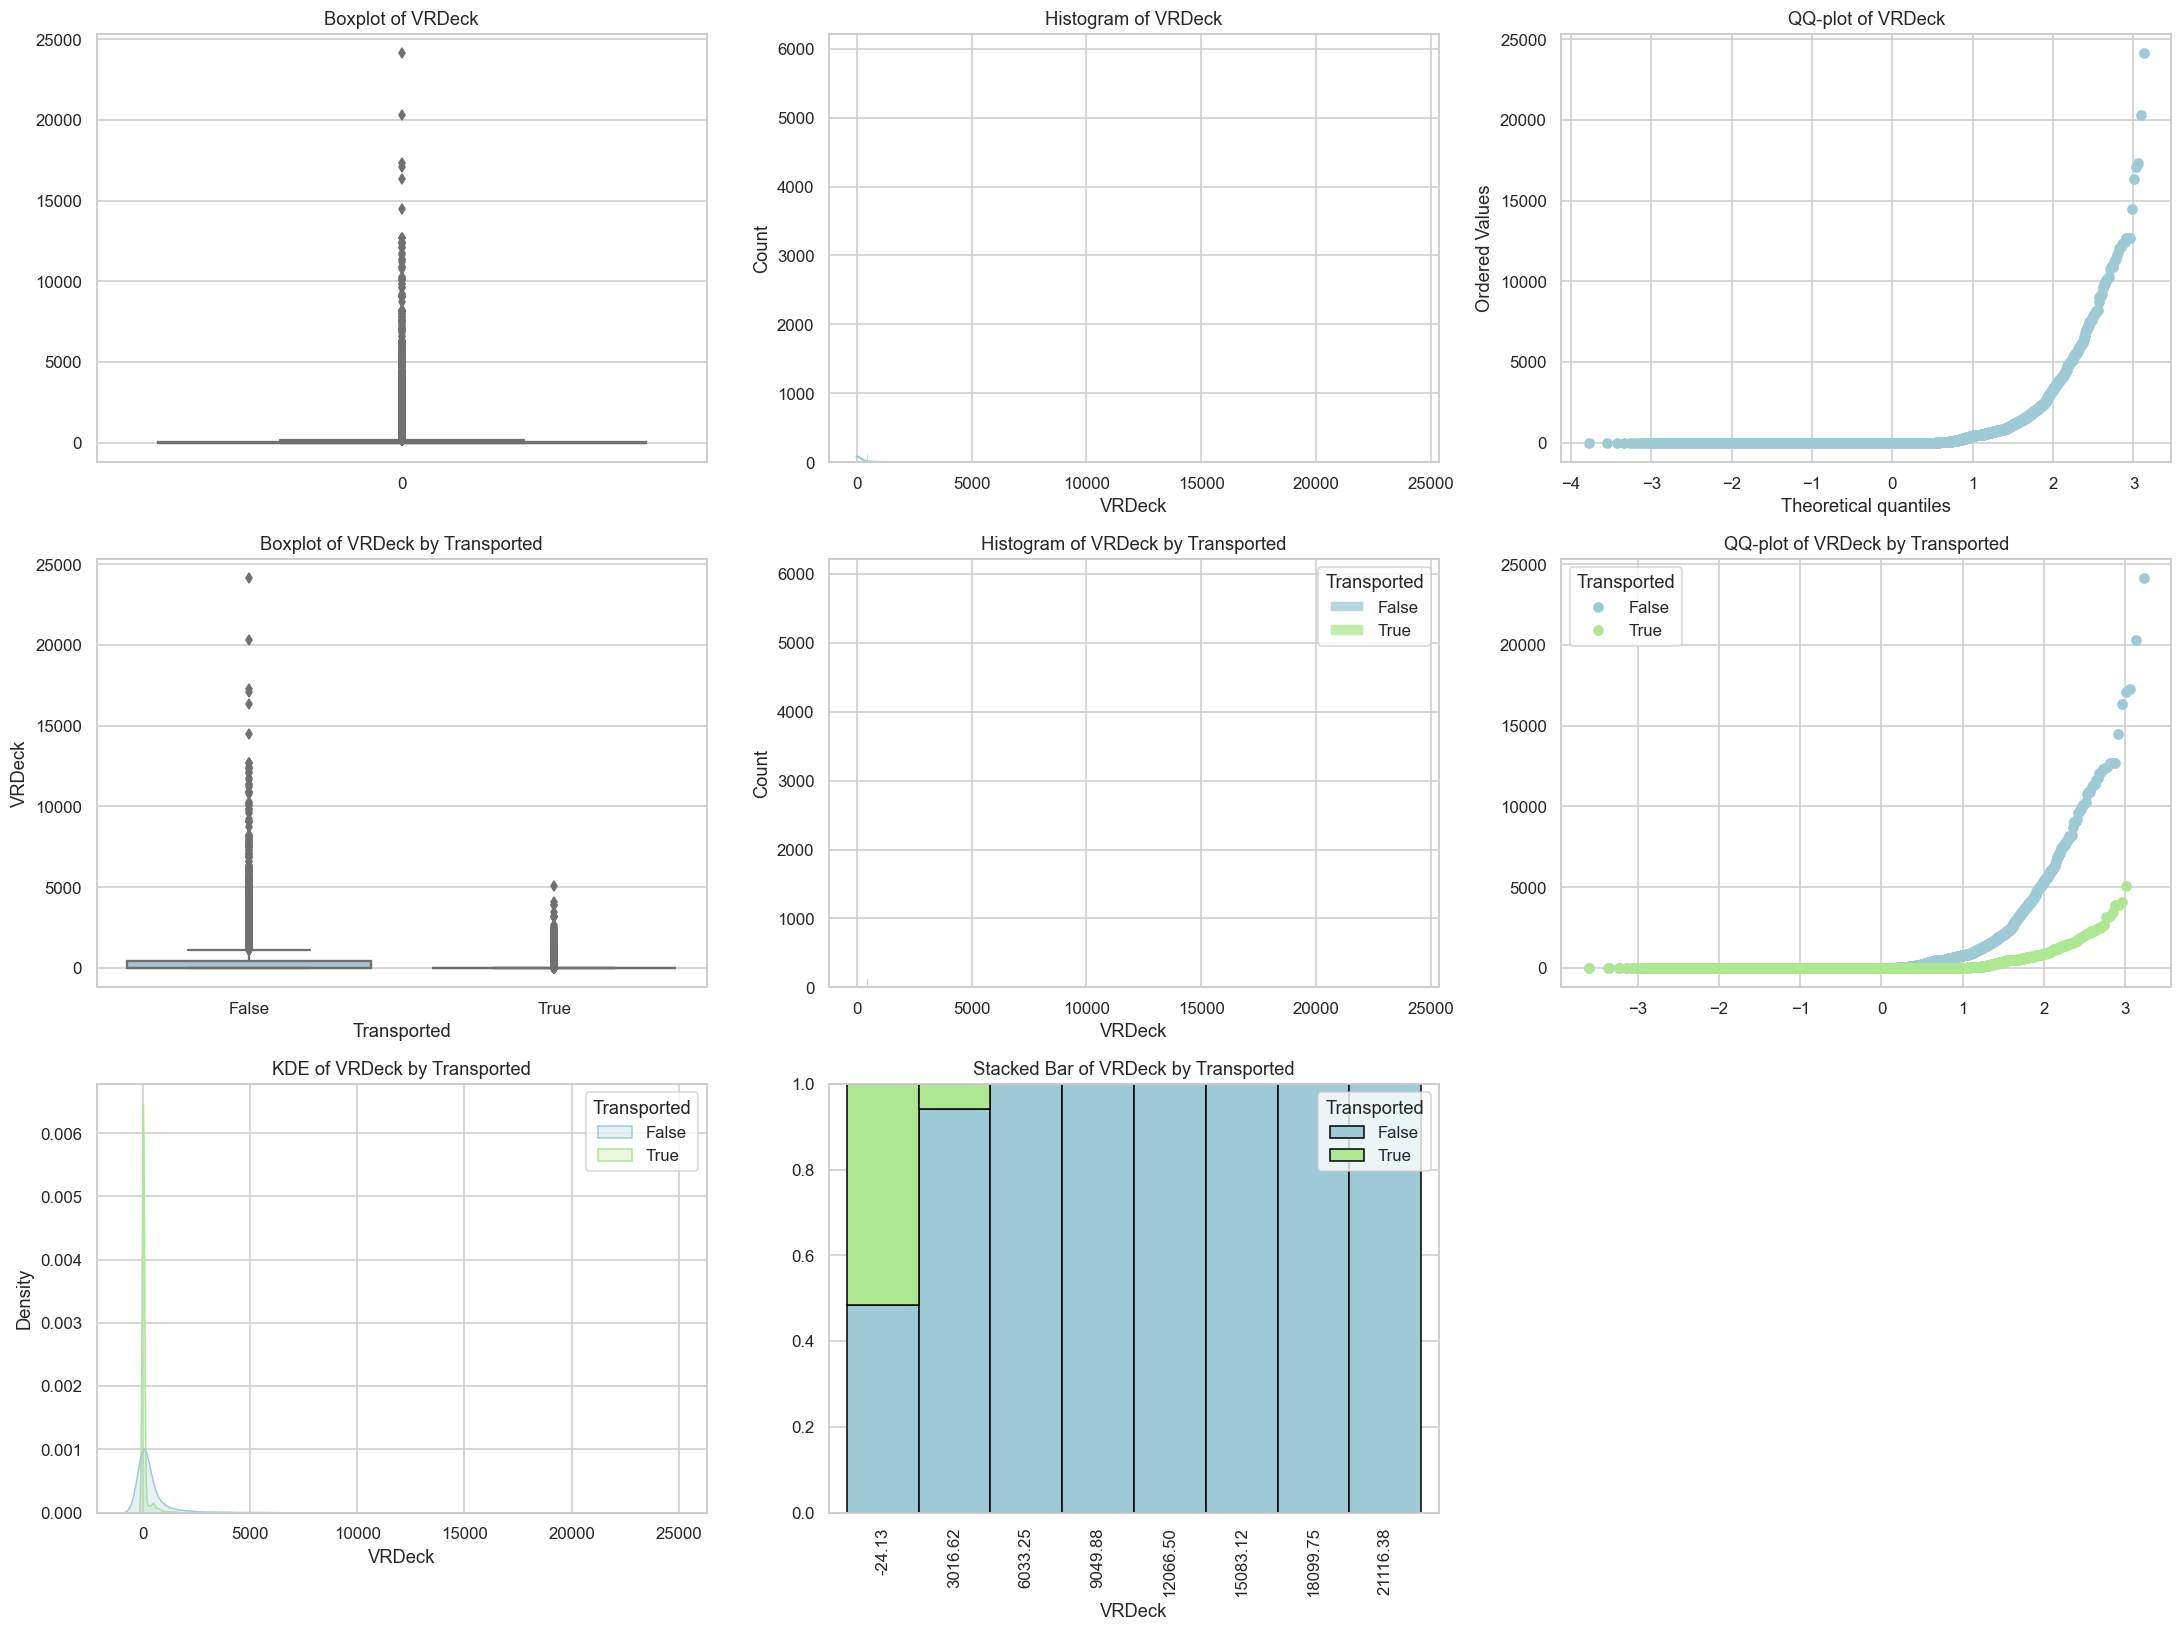

<Figure size 704x528 with 0 Axes>

(4313,)
(4373,)
0       0.0
2      49.0
3     193.0
13     24.0
15      0.0
Name: VRDeck, dtype: float64
1    44.0
4     2.0
5     0.0
6     0.0
7     0.0
Name: VRDeck, dtype: float64

VRDeck → p_value = 0.0000
❌ Significant difference → Reject H₀


In [538]:
analysis_numeric_col(df_train,"VRDeck")
mannwhitney_test(df_train,"VRDeck")

C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Reza.M\AppData\Roaming\Python\Python39\site-packages\seaborn\_oldcore.py:1075: FutureWarn

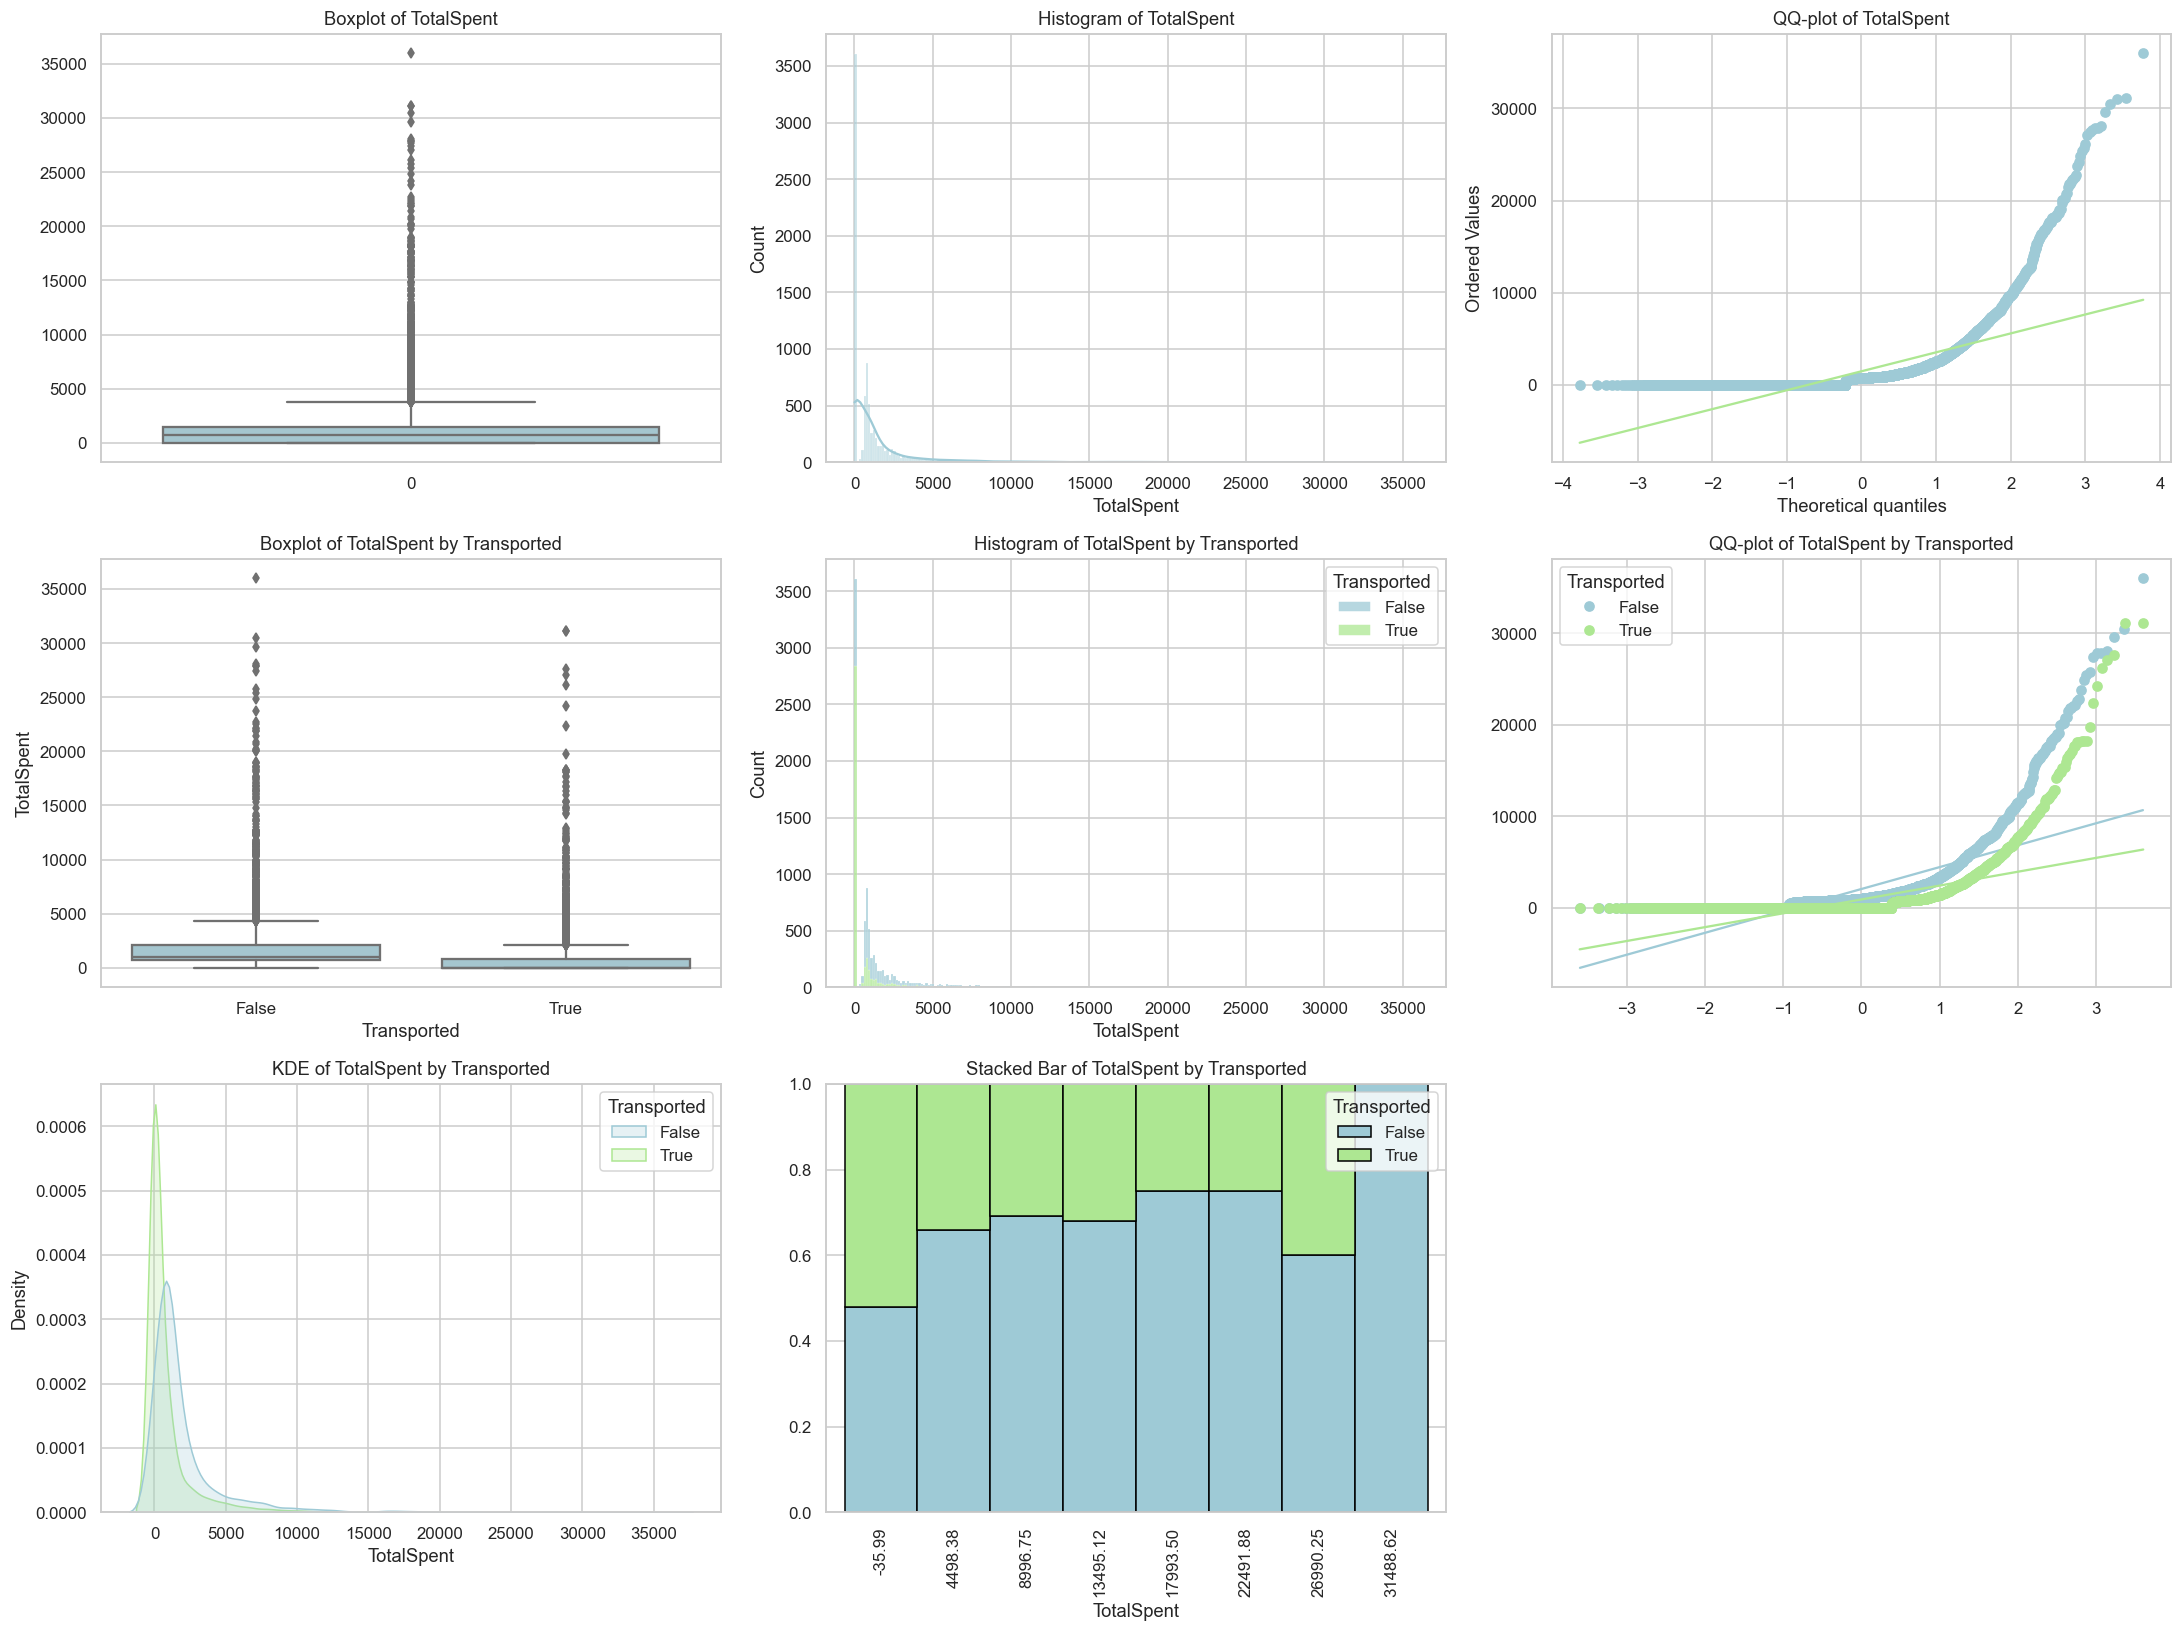

<Figure size 704x528 with 0 Axes>

(4315,)
(4378,)
0         0.0
2     10383.0
3      5176.0
13      809.0
15      908.0
Name: TotalSpent, dtype: float64
1     736.0
4    1091.0
5     774.0
6    1584.0
7       0.0
Name: TotalSpent, dtype: float64

TotalSpent → p_value = 0.0000
❌ Significant difference → Reject H₀


In [539]:
analysis_numeric_col(df_train,"TotalSpent")
mannwhitney_test(df_train,"TotalSpent")

## 6. Statistical analysis and hypothesis testing

Categorical feature frequencies and target proportions are reviewed alongside formal association tests. Chi-square or Fisher's exact tests assess whether observed target differences are unlikely under independence; Cram?r?s V quantifies association strength, and Bonferroni correction controls family-wise error in pairwise comparisons.


In [540]:
def freqencytable(col):
    value_count = col.value_counts()
    table = pd.DataFrame({'Proportion' :  value_count,
                          '%' : round(((value_count)/(value_count.sum()))*100,2)})
    return table
def count_category_target(data,cat_col,target_col):
    value_count_y = data[data[target_col]==1][cat_col].value_counts()
    value_count_n = data[data[target_col]==0][cat_col].value_counts()
#    value_count_n = round((data[data[target_col]==0][cat_col].value_counts())/(data[data[target_col]==0][cat_col].value_counts().sum())*100,2)
    table1 = pd.DataFrame({'Yes': value_count_y,
                           'NO' : value_count_n
                           })
    return table1
    
def percentage_category_target(data,cat_col,target_col):
    value_count_y = round((data[data[target_col]==1][cat_col].value_counts())/(data[cat_col].value_counts())*100,2)
    value_count_n = round((data[data[target_col]==0][cat_col].value_counts())/(data[cat_col].value_counts())*100,2)
    table2 = pd.DataFrame({'Yes': value_count_y,
                           'NO' : value_count_n
                           })
    return table2  

In [541]:
def category_target(data,cat_col,target_col,chart_type,ax=None):

    if chart_type == 'Category Frequency':
        ch1 = freqencytable(data[cat_col])
        tab1 = Table(ch1,textprops={"ha": "center", "va": "center", "fontsize": 12},ax=ax)
        ax.set_title('Category Frequency')

    elif chart_type == 'Count By Category & Target':
        ch2=count_category_target(data,cat_col,target_col)     
        tab2 = Table(ch2,textprops={"ha": "center", "va": "center", "fontsize": 12},ax=ax)
        ax.set_title('Count By Category & Target')

    elif chart_type == 'Percentage By Category & Target':  
        ch3 = percentage_category_target(data,cat_col,target_col)    
        tab3 = Table(ch3,textprops={"ha": "center", "va": "center", "fontsize": 12},ax=ax)
        ax.set_title('Percentage By Category & Target')

def bar_chart(data, cat_col, chart_type,ax=None):
    counts = pd.crosstab(data[cat_col], data['Transported'].map({True:'Yes', False:'No'}))
    counts = counts.sort_index()
    
    if chart_type == 'Frequency Bar Chart':
        data_sorted = data[cat_col].value_counts().sort_index()
        sns.barplot(x=data_sorted.index, y=data_sorted.values, color= "#9ECAD6",ax=ax)
        ax.set_ylabel('Frequency')
        ax.set_title('Frequency Bar Chart')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    
    elif chart_type == 'Grouped Bar Chart':
        counts.plot(kind='bar', color= ["#9ECAD6", "#ADE792"],ax=ax)
        ax.set_ylabel('Count')
        ax.set_title('Grouped Bar Chart')
    
    elif chart_type == 'Normalized Stacked Bar Chart':     
        norm_c = counts.div(counts.sum(axis=1), axis=0)
        norm_c.plot(kind='bar', stacked=True, color= ["#9ECAD6", "#ADE792"],ax=ax)
        ax.set_ylabel('Proportion')
        ax.set_title('Normalized Stacked Bar Chart')
                
def categorical_data(data,col_name,target_col):
    fig, axes = plt.subplots(2, 3, figsize = (20, 12),constrained_layout=True)
    fig.suptitle(col_name, fontsize=18, fontweight='bold')
    tab1 = category_target(data,col_name,target_col,'Category Frequency',ax=axes[0,0])
    tab2 = category_target(data,col_name,target_col,'Count By Category & Target',ax=axes[0,1])
    tab3 = category_target(data,col_name,target_col,'Percentage By Category & Target',ax=axes[0,2])
    bar1 = bar_chart(data,col_name,'Frequency Bar Chart',ax=axes[1,0]) 
    bar2 = bar_chart(data,col_name,'Grouped Bar Chart',ax=axes[1,1]) 
    bar3 = bar_chart(data,col_name,'Normalized Stacked Bar Chart',ax=axes[1,2])  

In [542]:
def analyze_campaign_Transported(data,col_name, target_col):
    data = data.dropna(subset=[col_name, target_col]).copy()

    results = {}

    contingency = pd.crosstab(data[col_name], data[target_col])
    n = contingency.sum().sum() 
    r, k = contingency.shape     


    # آزمون کلی Chi-Square
    
    if contingency.shape == (2,2):
        oddsratio, p_fisher = fisher_exact(contingency)
        results['overall_test'] = {
            'type': 'Fisher Exact',
            'p-value': p_fisher,
            'oddsratio': oddsratio
        }
    else:
        chi2, p, dof, expected = chi2_contingency(contingency)
        results['overall_test'] = {
            'type': 'Chi-Square',
            'Chi2': chi2,
            'p-value': p,
            'dof': dof
        }

        # Cramér's V
        phi2 = chi2 / n
        cramers_v = np.sqrt(phi2 / min(r-1, k-1))
        results['cramers_v'] = cramers_v

    # مقایسه زوجی (Pairwise)
    categories = data[col_name].unique()
    pairs = list(itertools.combinations(categories, 2))
    pairwise_results = []

    for pair in pairs:
        subset = data[data[col_name].isin(pair)]
        contingency_pair = pd.crosstab(subset[col_name], subset[target_col])
        chi2, pval, dof, expected = chi2_contingency(contingency_pair)
        pairwise_results.append({"Pair": pair, "p-value": pval})

    # اصلاح چندگانه (Bonferroni)
    pvals = [r["p-value"] for r in pairwise_results]
    reject, pvals_corrected, _, _ = smm.multipletests(pvals, method="bonferroni")

    for i, r in enumerate(pairwise_results):
        r["p-corrected"] = pvals_corrected[i]
        r["Significant"] = reject[i]

    results['pairwise'] = pd.DataFrame(pairwise_results)

    return results

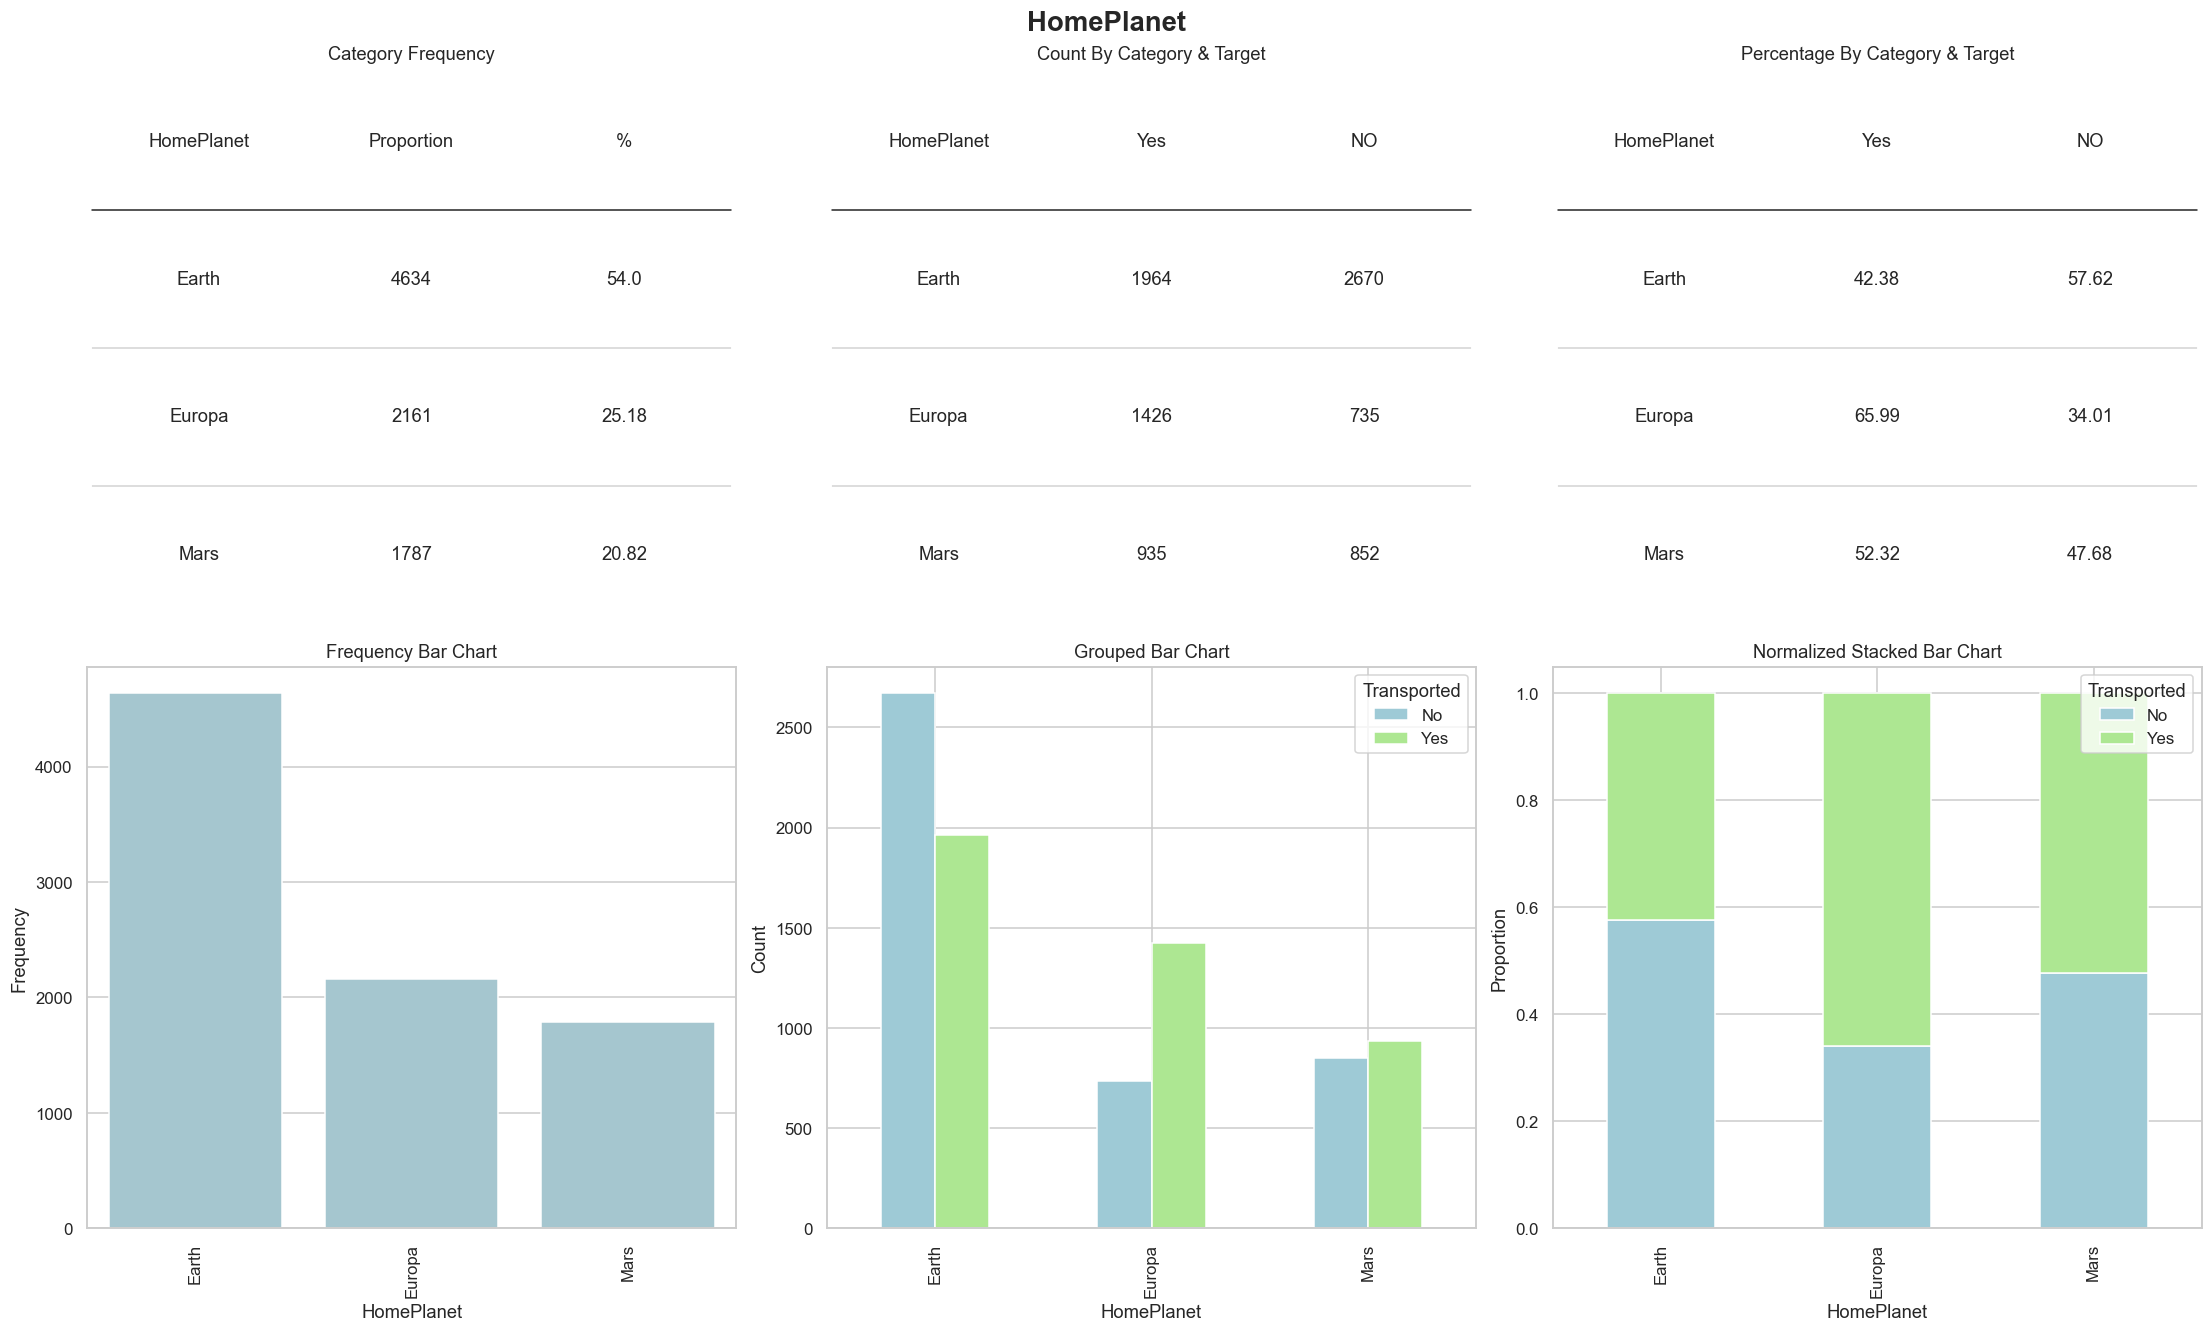

In [543]:
categorical_data(df_train,'HomePlanet','Transported')

In [544]:
analyze_campaign_Transported(df_train,'HomePlanet','Transported')

{'overall_test': {'type': 'Chi-Square',
  'Chi2': np.float64(331.851460663768),
  'p-value': np.float64(8.697028857334735e-73),
  'dof': 2},
 'cramers_v': np.float64(0.19664260175494905),
 'pairwise':               Pair       p-value   p-corrected  Significant
 0  (Europa, Earth)  3.301691e-73  9.905074e-73         True
 1   (Europa, Mars)  3.804524e-18  1.141357e-17         True
 2    (Earth, Mars)  8.992041e-13  2.697612e-12         True}

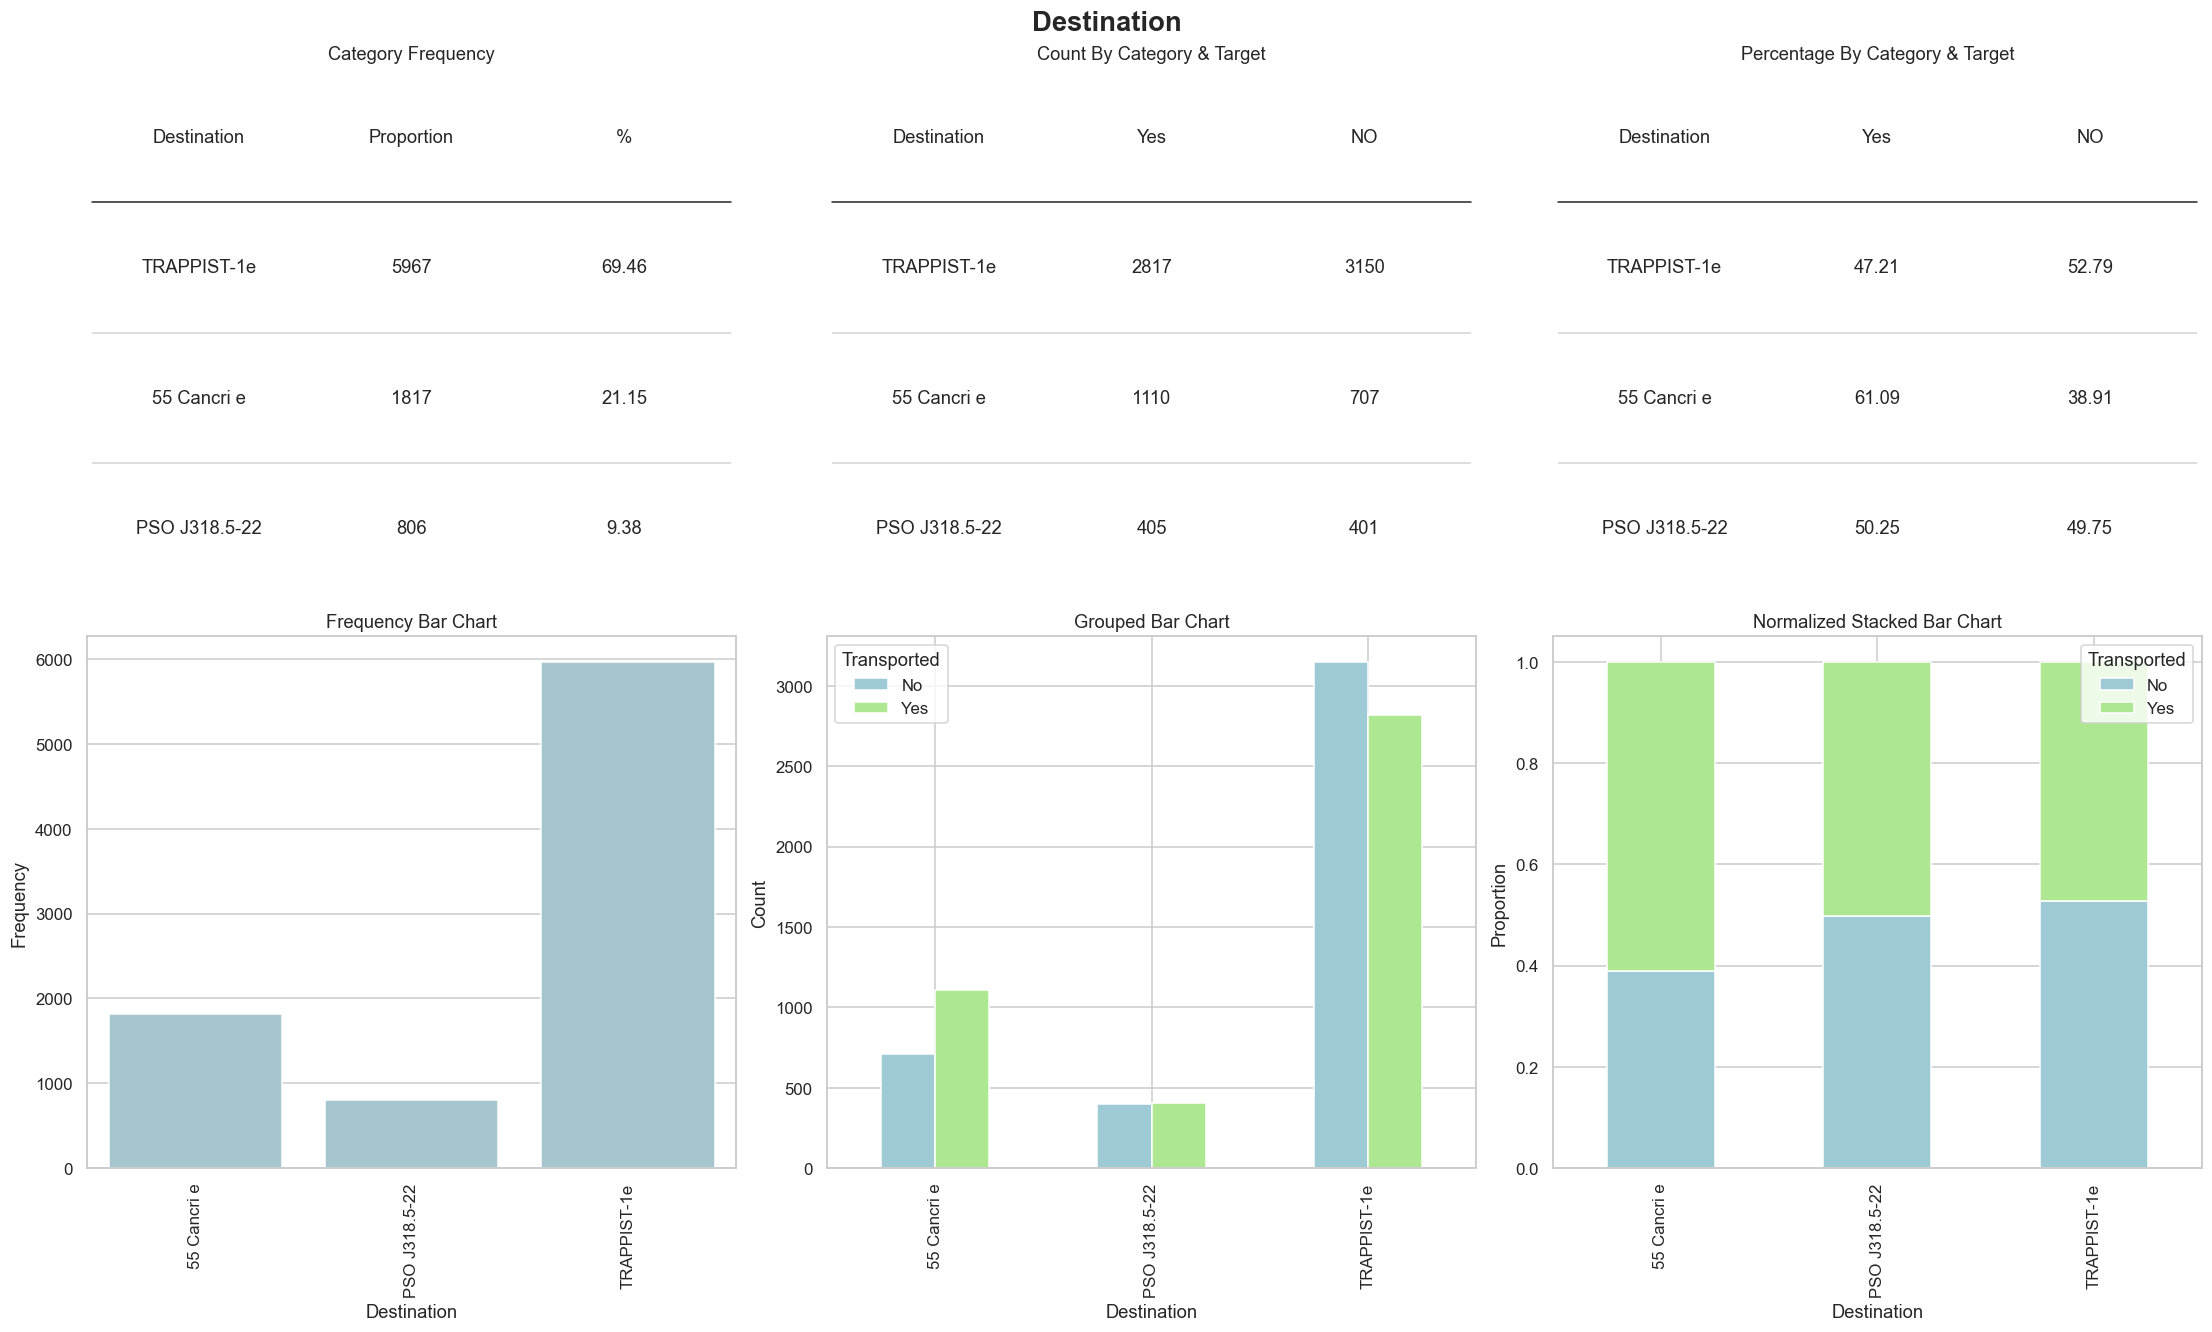

In [545]:
categorical_data(df_train,'Destination','Transported')

In [546]:
analyze_campaign_Transported(df_train,'Destination','Transported')

{'overall_test': {'type': 'Chi-Square',
  'Chi2': np.float64(107.35709229663462),
  'p-value': np.float64(4.871958847033846e-24),
  'dof': 2},
 'cramers_v': np.float64(0.1117940753565393),
 'pairwise':                            Pair       p-value   p-corrected  Significant
 0  (TRAPPIST-1e, PSO J318.5-22)  1.132625e-01  3.397874e-01        False
 1    (TRAPPIST-1e, 55 Cancri e)  4.945783e-25  1.483735e-24         True
 2  (PSO J318.5-22, 55 Cancri e)  2.696816e-07  8.090448e-07         True}

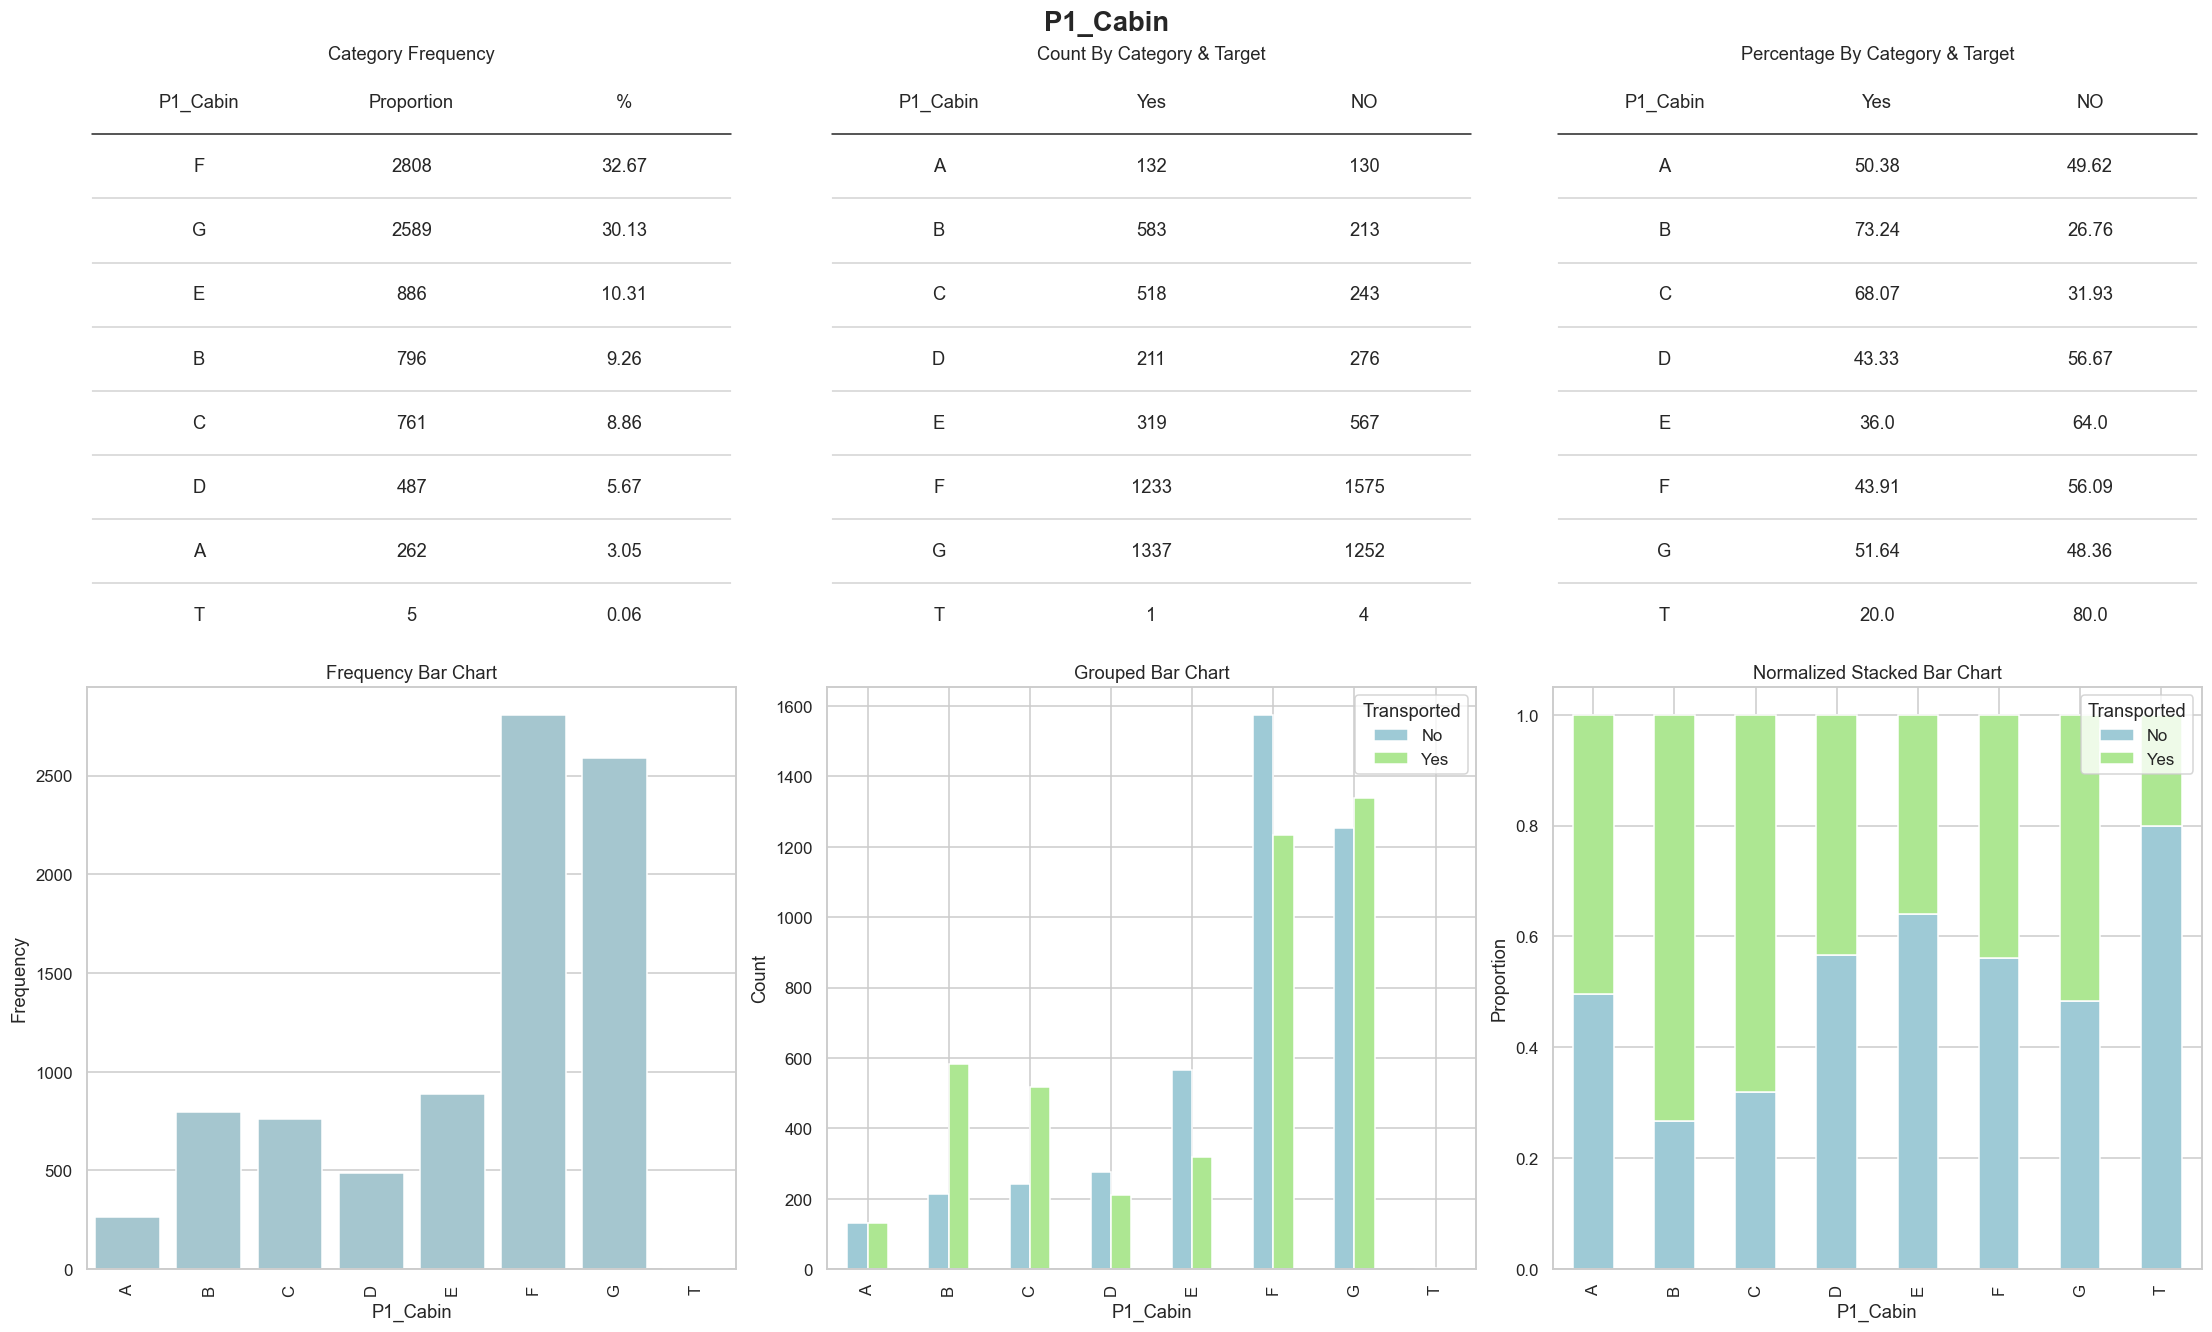

In [547]:
categorical_data(df_train,'P1_Cabin','Transported')

In [548]:
analyze_campaign_Transported(df_train,'P1_Cabin','Transported')

{'overall_test': {'type': 'Chi-Square',
  'Chi2': np.float64(395.10578967387744),
  'p-value': np.float64(2.673024427924849e-81),
  'dof': 7},
 'cramers_v': np.float64(0.21441690463115962),
 'pairwise':       Pair       p-value   p-corrected  Significant
 0   (B, F)  4.408409e-48  1.234355e-46         True
 1   (B, A)  1.196379e-11  3.349860e-10         True
 2   (B, G)  8.581064e-27  2.402698e-25         True
 3   (B, E)  1.889136e-52  5.289582e-51         True
 4   (B, D)  1.792145e-26  5.018006e-25         True
 5   (B, C)  2.878880e-02  8.060864e-01        False
 6   (B, T)  3.033806e-02  8.494656e-01        False
 7   (F, A)  5.105729e-02  1.000000e+00        False
 8   (F, G)  1.565406e-08  4.383138e-07         True
 9   (F, E)  3.826939e-05  1.071543e-03         True
 10  (F, D)  8.491359e-01  1.000000e+00        False
 11  (F, C)  4.735317e-32  1.325889e-30         True
 12  (F, T)  5.316701e-01  1.000000e+00        False
 13  (A, G)  7.459479e-01  1.000000e+00        False
 14

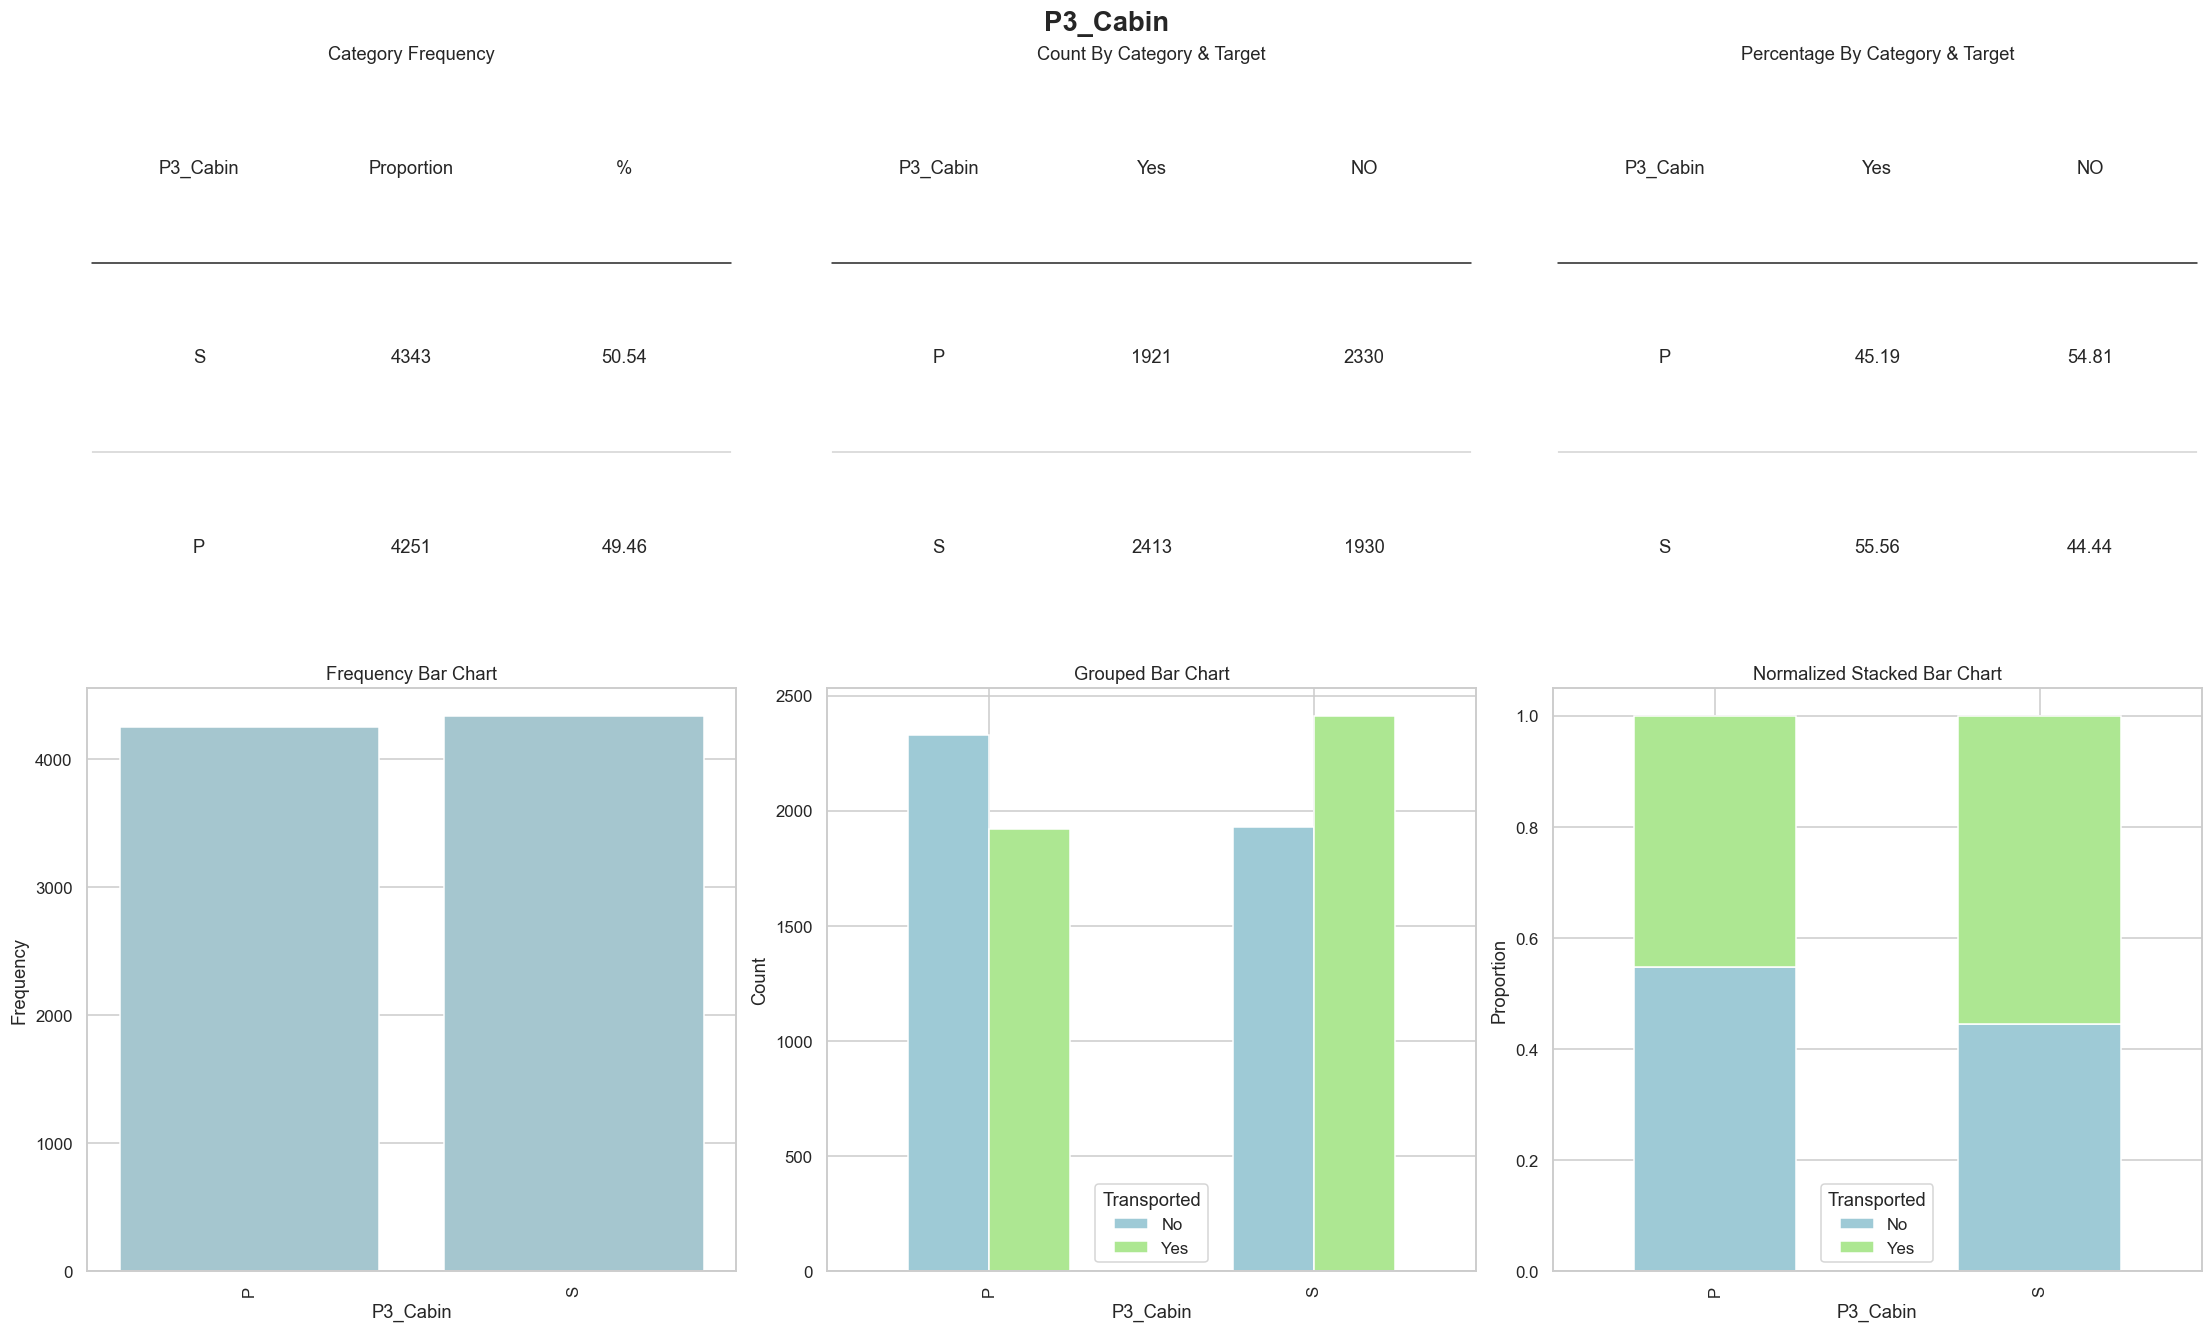

In [549]:
categorical_data(df_train,'P3_Cabin','Transported')

In [550]:
analyze_campaign_Transported(df_train,'P3_Cabin','Transported')

{'overall_test': {'type': 'Fisher Exact',
  'p-value': np.float64(7.287091264697355e-22),
  'oddsratio': np.float64(1.516451653796463)},
 'pairwise':      Pair       p-value   p-corrected  Significant
 0  (P, S)  8.570443e-22  8.570443e-22         True}

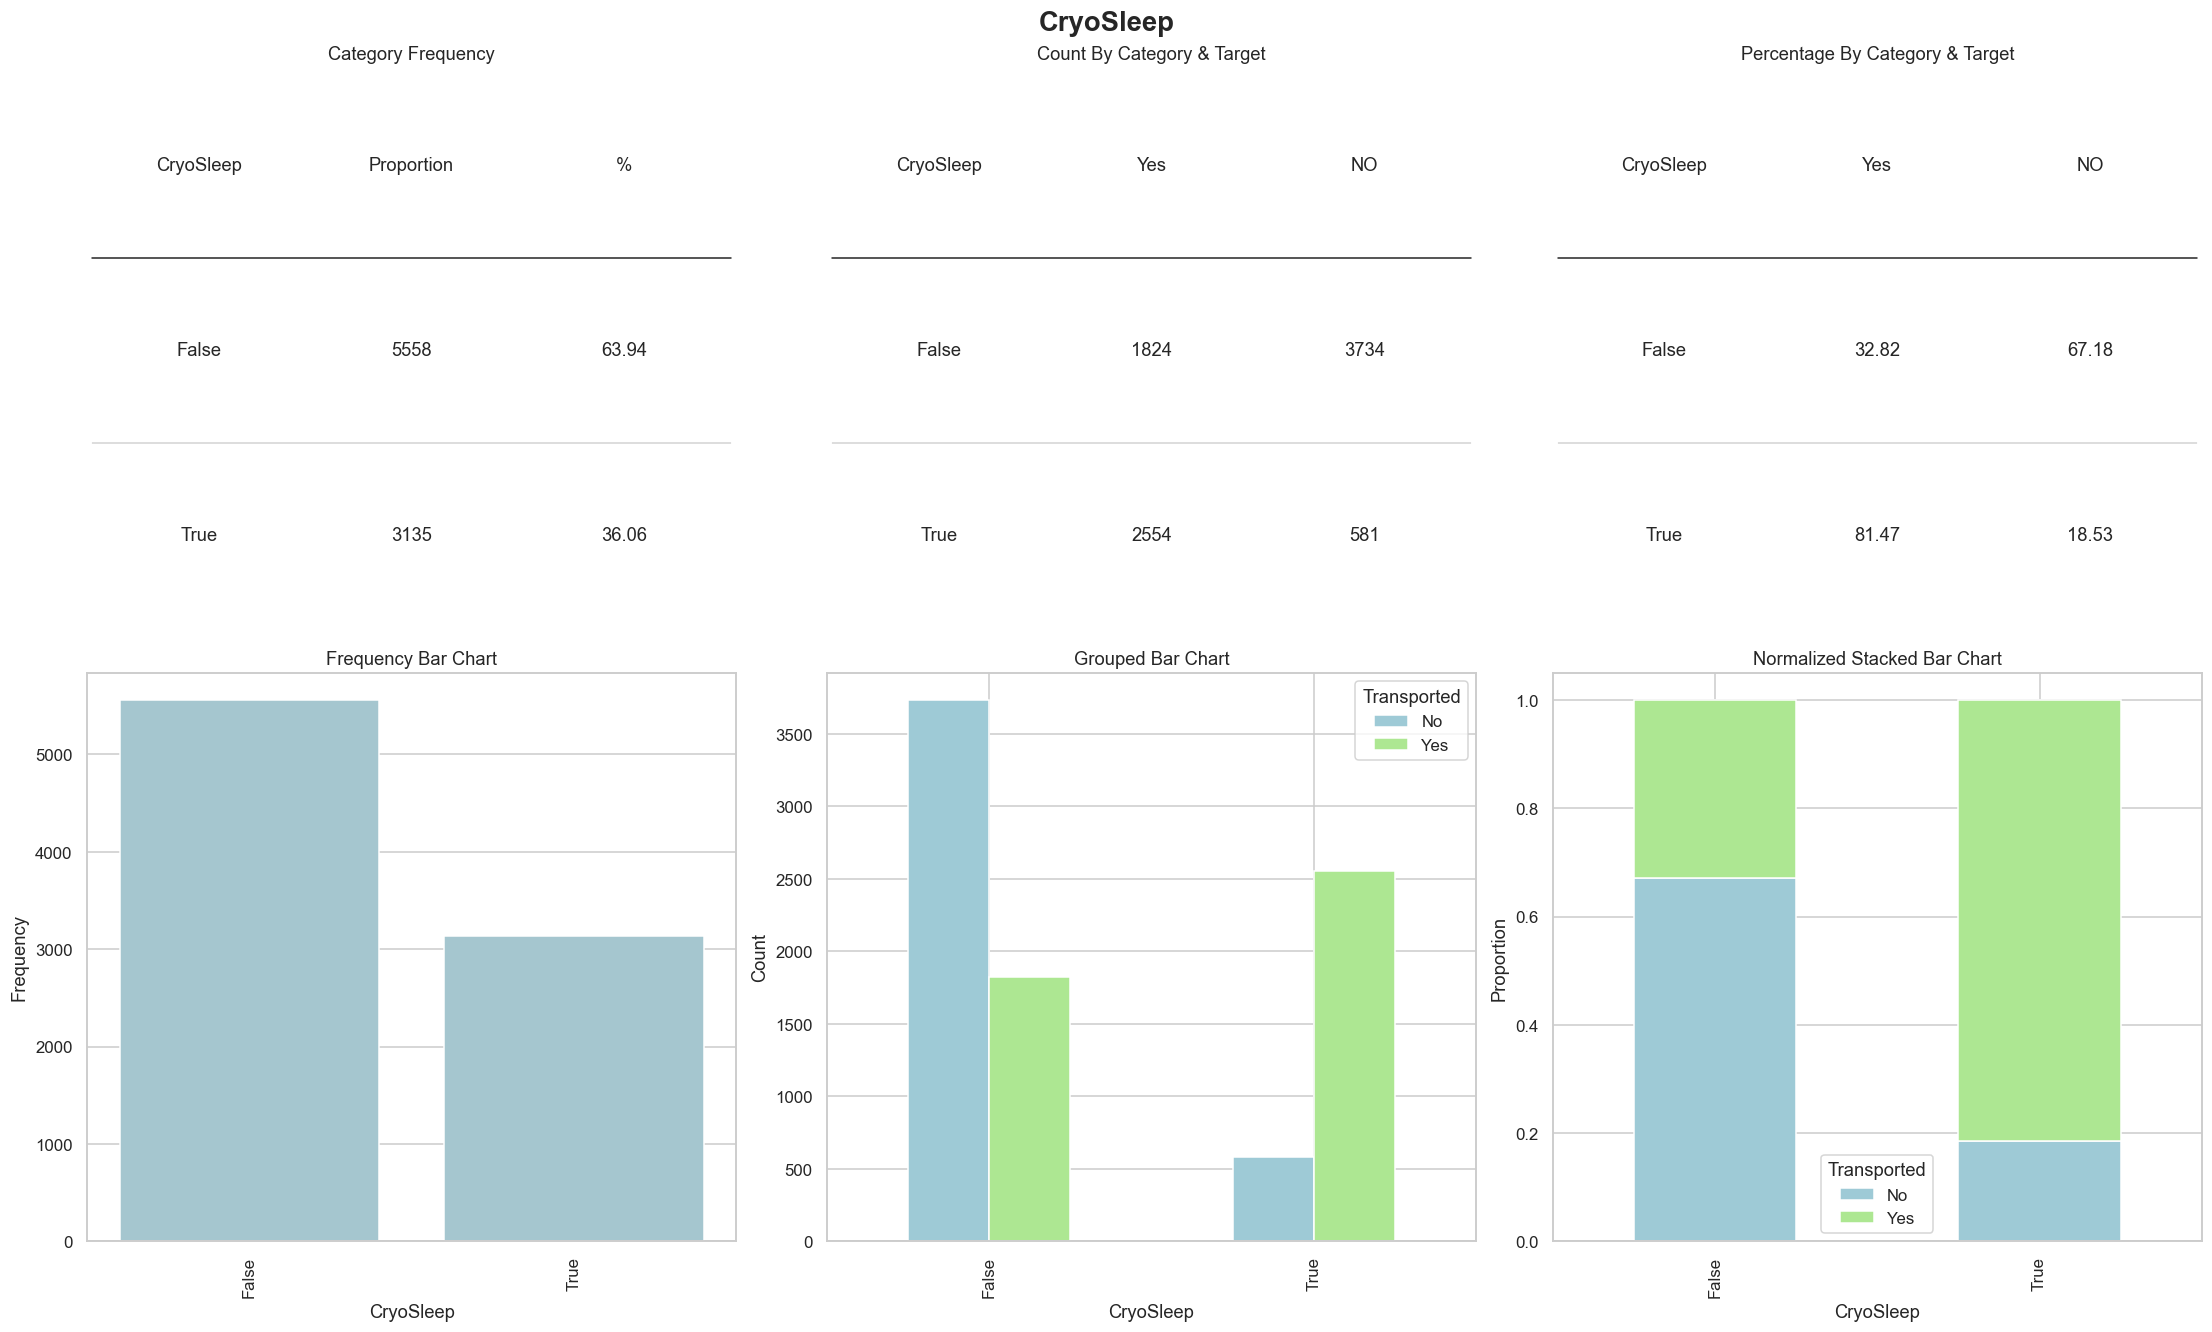

In [551]:
categorical_data(df_train,'CryoSleep','Transported')

In [552]:
analyze_campaign_Transported(df_train,'CryoSleep','Transported')

{'overall_test': {'type': 'Fisher Exact',
  'p-value': np.float64(0.0),
  'oddsratio': np.float64(8.998999758432225)},
 'pairwise':             Pair  p-value  p-corrected  Significant
 0  (False, True)      0.0          0.0         True}

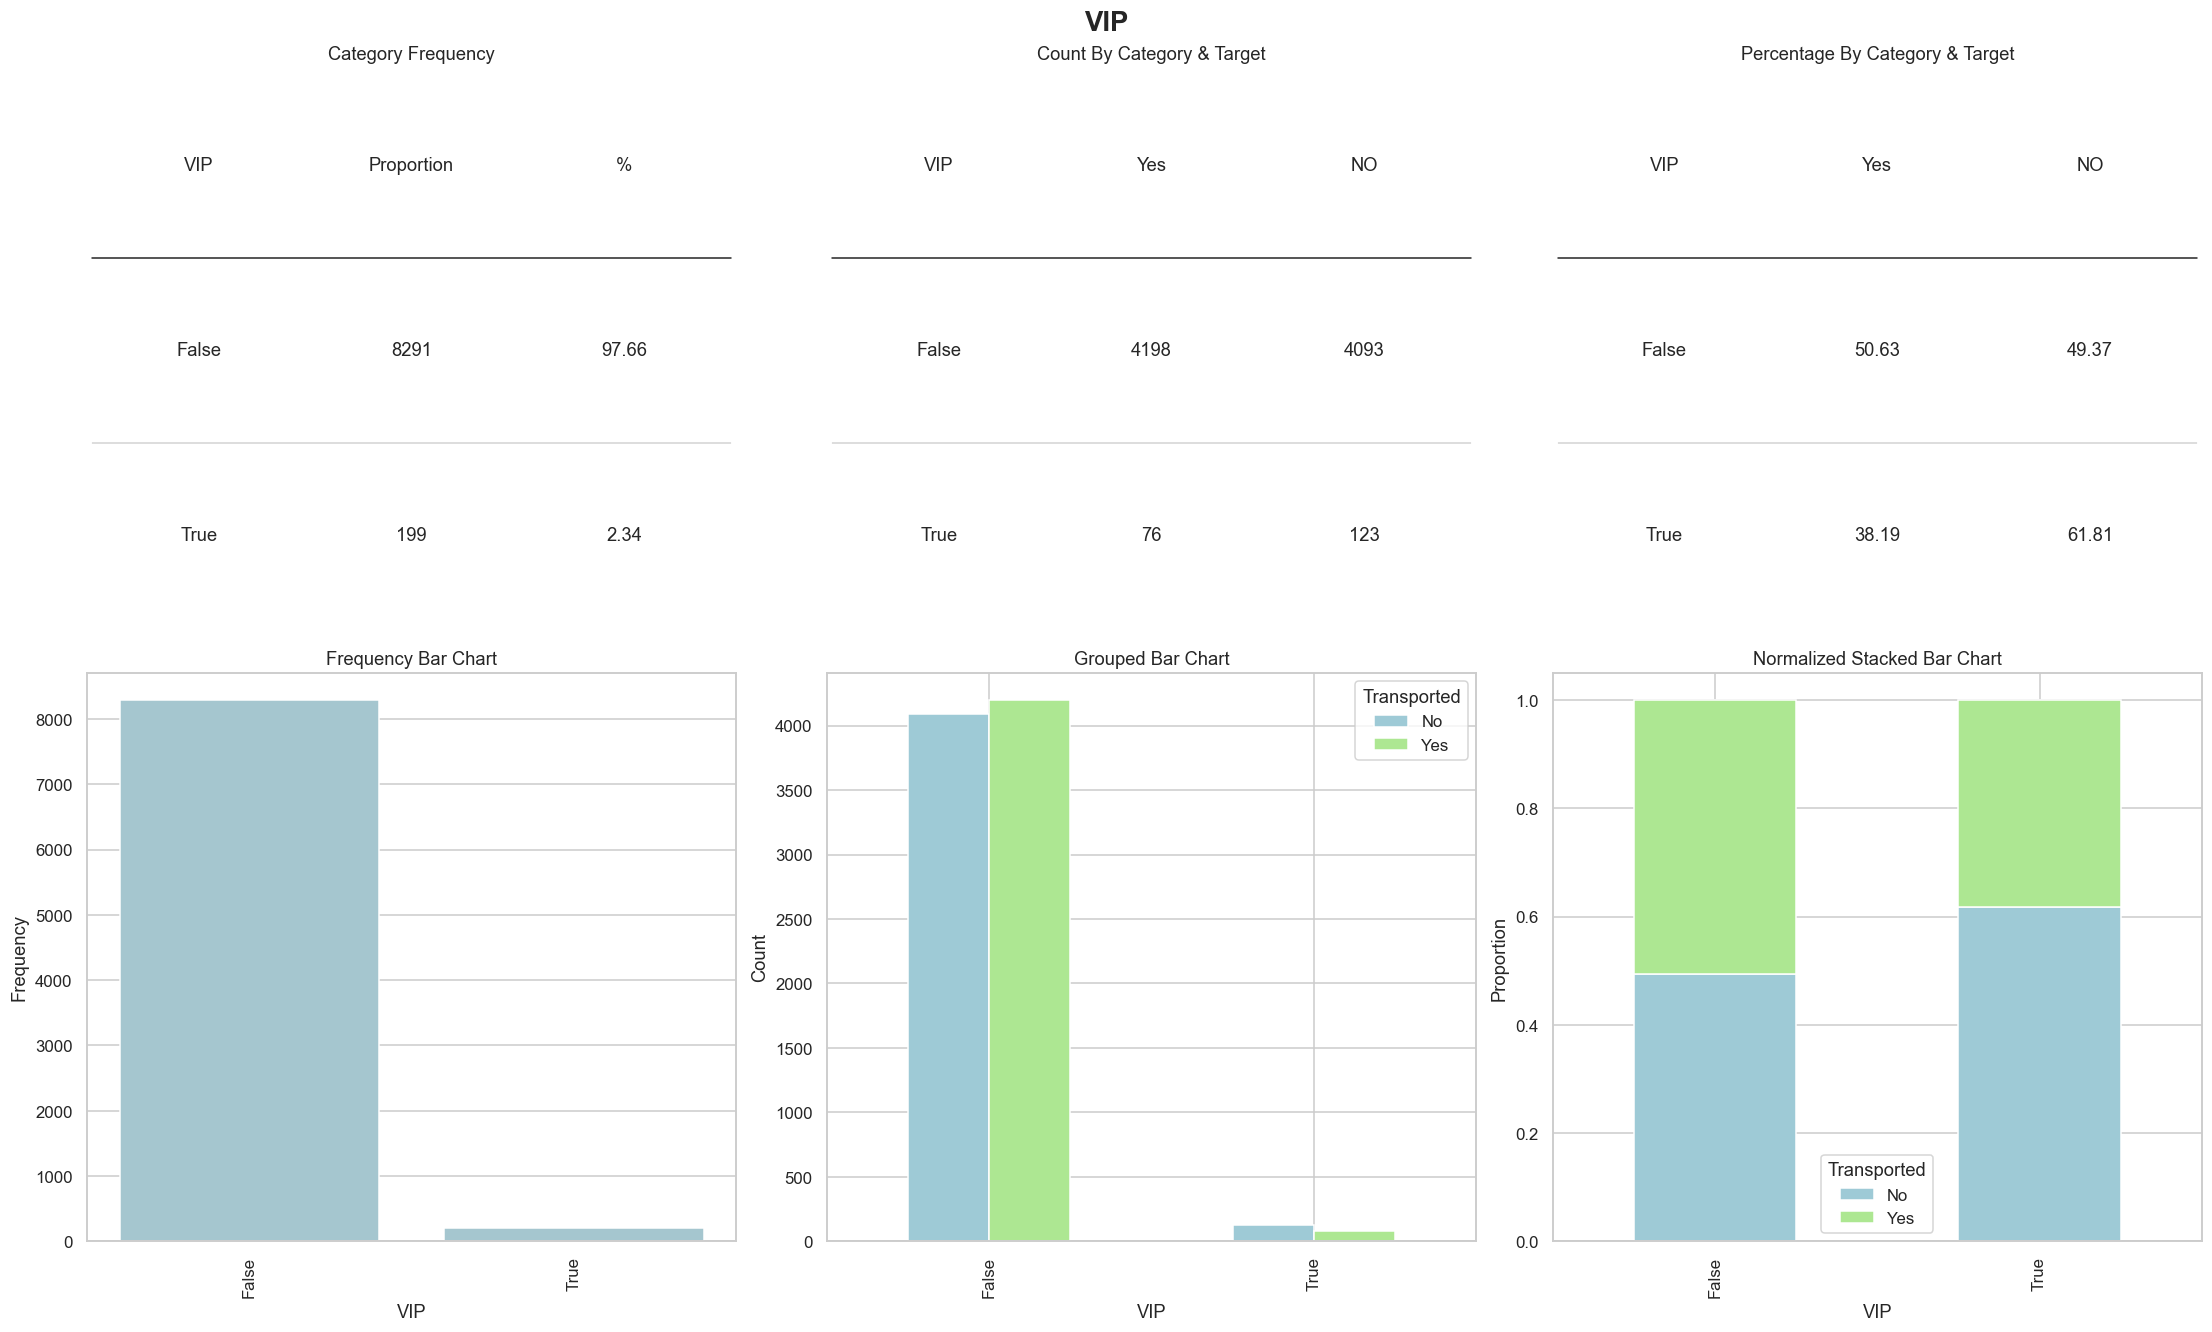

In [553]:
categorical_data(df_train,'VIP','Transported')

In [554]:
analyze_campaign_Transported(df_train,'VIP','Transported')

{'overall_test': {'type': 'Fisher Exact',
  'p-value': np.float64(0.0005511191844286785),
  'oddsratio': np.float64(0.6024316650979754)},
 'pairwise':             Pair  p-value  p-corrected  Significant
 0  (False, True)  0.00068      0.00068         True}

In [555]:
print(df_train['CryoSleep'].unique())
print(df_train['HomePlanet'].unique())
print(df_train['Destination'].unique())
print(df_train['P1_Cabin'].unique()) 
print(df_train['P2_Cabin'].unique())
print(df_train['P3_Cabin'].unique()) 

[False True]
['Europa' 'Earth' 'Mars' nan]
['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e' nan]
['B' 'F' 'A' 'G' nan 'E' 'D' 'C' 'T']
['0' '1' '2' ... '1892' '1893' '1894']
['P' 'S' None]


## 7. Feature engineering

The cabin components and `CabinBlock` retain the location signal discovered during EDA. Categorical variables are encoded for the original tree-model experiments while preserving missingness for inspection. These transformations implement the analytical decisions made above rather than introducing a new modelling approach.


In [556]:
df_train["P2_Cabin"] = pd.to_numeric(
    df_train["P2_Cabin"],
    errors="coerce"
)

df_train["CabinBlock"] = pd.cut(
    df_train["P2_Cabin"],
    bins=5,
    labels=False
)

In [557]:
df_train['CryoSleepLikely'] = np.where(df_train['CryoSleep'].notna(), df_train['CryoSleep'].astype(str), np.where(df_train['TotalSpent'].eq(0), 'likely_true', 'likely_false'))
df_train['AgeBand'] = pd.cut(df_train['Age'], bins=[-1, 12, 18, 30, 45, 60, np.inf], labels=['child', 'teen', 'young_adult', 'adult', 'middle_age', 'senior'])

In [558]:
df_train["CabinSize"] = (
    df_train.groupby("Cabin")["Cabin"]
      .transform("count")
).astype(str)

In [559]:
df_train = df_train.drop(['PassengerId', 'Name','Cabin','GroupID',"P2_Cabin"], axis=1)

In [560]:
df_train.head(5)

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,TotalSpent,P1_Cabin,P3_Cabin,CabinBlock,CryoSleepLikely,AgeBand,CabinSize
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,0.0,B,P,0.0,False,adult,1.0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,736.0,F,S,0.0,False,young_adult,1.0
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,10383.0,A,S,0.0,False,middle_age,2.0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,5176.0,A,S,0.0,False,adult,2.0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,1091.0,F,S,0.0,False,teen,1.0


## 8. Data preprocessing & Model training & Validation

The engineered training data is split with stratification to preserve the class balance in both subsets. Scaling is included for the current comparison workflow so model inputs use a consistent numerical range.
The notebook compares several established tree-based classifiers?Random Forest, XGBoost, LightGBM, and CatBoost?on the same holdout split. This comparison tests whether different boosting and bagging approaches can exploit the engineered passenger and cabin signals.


In [561]:
y_train = df_train['Transported'].astype(int)
df_train = df_train.drop(columns=['Transported'])

In [562]:
numeric_features = df_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = df_train.select_dtypes(exclude=['number']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', SimpleImputer(strategy='median'), numeric_features),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_features),
    ]
)



In [563]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=700,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    random_seed=42,
    verbose=0
)

In [564]:
pipeline = Pipeline([('preprocess', preprocessor), ('model', cat)])

In [565]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scores = cross_validate(
    pipeline, df_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1, return_train_score=True
)
results = pd.DataFrame({
    'fold': np.arange(1, N_SPLITS + 1),
    'train_accuracy': scores['train_score'],
    'validation_accuracy': scores['test_score'],
})
display(results.style.format({'train_accuracy': '{:.4f}', 'validation_accuracy': '{:.4f}'}))
print(f"Mean CV accuracy: {results['validation_accuracy'].mean():.4f} ± {results['validation_accuracy'].std():.4f}")

,fold,train_accuracy,validation_accuracy
0,1,0.8722,0.8212
1,2,0.8700,0.8114
2,3,0.8739,0.8206
3,4,0.8778,0.8228
4,5,0.8776,0.8044


Mean CV accuracy: 0.8161 ± 0.0079


In [566]:
from xgboost import XGBClassifier

model_x = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)
pipeline_2 = Pipeline([('preprocess', preprocessor), ('model', model_x)])
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scores = cross_validate(
    pipeline_2, df_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1, return_train_score=True
)
results = pd.DataFrame({
    'fold': np.arange(1, N_SPLITS + 1),
    'train_accuracy': scores['train_score'],
    'validation_accuracy': scores['test_score'],
})
display(results.style.format({'train_accuracy': '{:.4f}', 'validation_accuracy': '{:.4f}'}))
print(f"Mean CV accuracy: {results['validation_accuracy'].mean():.4f} ± {results['validation_accuracy'].std():.4f}")

,fold,train_accuracy,validation_accuracy
0,1,0.9264,0.8177
1,2,0.9264,0.8114
2,3,0.9268,0.8051
3,4,0.9257,0.8182
4,5,0.9255,0.7998


Mean CV accuracy: 0.8104 ± 0.0080


In [567]:
from sklearn.ensemble import ExtraTreesClassifier
model_t= ExtraTreesClassifier(
    n_estimators=700,
    max_features=0.8,
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

pipeline_3 = Pipeline([('preprocess', preprocessor), ('model', model_t)])
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scores = cross_validate(
    pipeline_3, df_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1, return_train_score=True
)
results = pd.DataFrame({
    'fold': np.arange(1, N_SPLITS + 1),
    'train_accuracy': scores['train_score'],
    'validation_accuracy': scores['test_score'],
})
display(results.style.format({'train_accuracy': '{:.4f}', 'validation_accuracy': '{:.4f}'}))
print(f"Mean CV accuracy: {results['validation_accuracy'].mean():.4f} ± {results['validation_accuracy'].std():.4f}")

,fold,train_accuracy,validation_accuracy
0,1,0.9659,0.8079
1,2,0.9682,0.8016
2,3,0.9669,0.7959
3,4,0.9669,0.8113
4,5,0.9672,0.7934


Mean CV accuracy: 0.8020 ± 0.0076


## 9. Model evaluation and feature importance

Accuracy provides the competition-aligned holdout metric. Built-in and permutation importance are then inspected to check whether the trained model relies on the features motivated by EDA and to identify candidates for refinement.


,feature,importance
6,numeric__TotalSpent,10.475069
4,numeric__Spa,9.378909
5,numeric__VRDeck,8.383129
7,numeric__CabinBlock,7.724356
2,numeric__FoodCourt,6.965644
8,categorical__HomePlanet_Earth,6.957047
1,numeric__RoomService,5.392560
3,numeric__ShoppingMall,4.124549
0,numeric__Age,3.973514
9,categorical__HomePlanet_Europa,3.620300


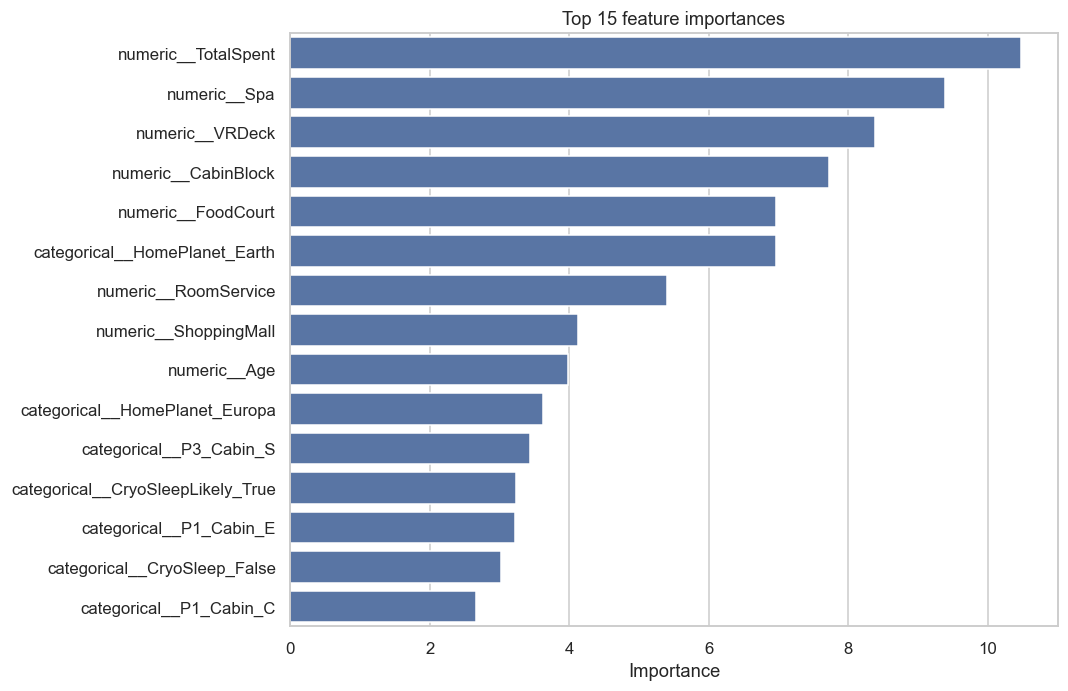

In [568]:
pipeline.fit(df_train, y_train)

feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
importance = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': pipeline.named_steps['model'].feature_importances_,
    })
    .sort_values('importance', ascending=False)
)
display(importance.head(20))

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=importance.head(15), x='importance', y='feature', ax=ax, color='#4C72B0')
ax.set(title='Top 15 feature importances', xlabel='Importance', ylabel='')
plt.show()

,feature,importance
29,categorical__CryoSleepLikely_False,0.188298
11,categorical__CryoSleep_False,0.128159
12,categorical__CryoSleep_True,0.117008
8,categorical__HomePlanet_Earth,0.081350
9,categorical__HomePlanet_Europa,0.037566
6,numeric__TotalSpent,0.031021
22,categorical__P1_Cabin_E,0.027609
32,categorical__AgeBand_child,0.024360
27,categorical__P3_Cabin_S,0.018746
24,categorical__P1_Cabin_G,0.018389


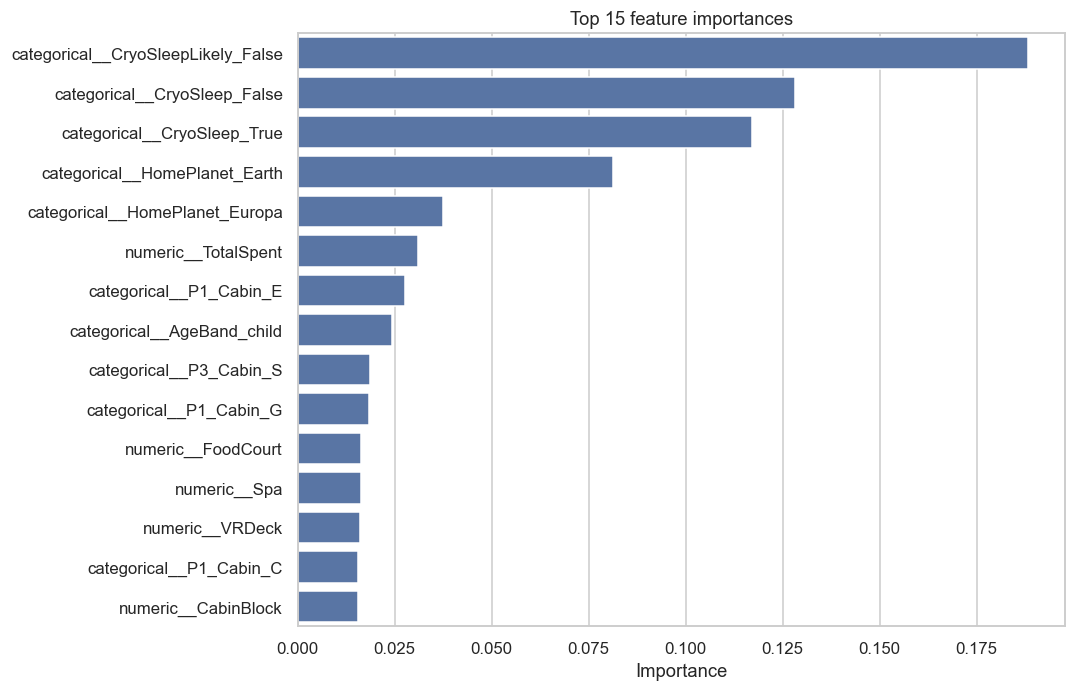

In [569]:
pipeline_2.fit(df_train, y_train)

feature_names = pipeline_2.named_steps['preprocess'].get_feature_names_out()
importance = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': pipeline_2.named_steps['model'].feature_importances_,
    })
    .sort_values('importance', ascending=False)
)
display(importance.head(20))

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=importance.head(15), x='importance', y='feature', ax=ax, color='#4C72B0')
ax.set(title='Top 15 feature importances', xlabel='Importance', ylabel='')
plt.show()

,feature,importance
11,categorical__CryoSleep_False,0.136071
29,categorical__CryoSleepLikely_False,0.134740
2,numeric__FoodCourt,0.066929
7,numeric__CabinBlock,0.062862
4,numeric__Spa,0.057151
0,numeric__Age,0.055126
3,numeric__ShoppingMall,0.054474
5,numeric__VRDeck,0.054032
8,categorical__HomePlanet_Earth,0.046027
1,numeric__RoomService,0.035615


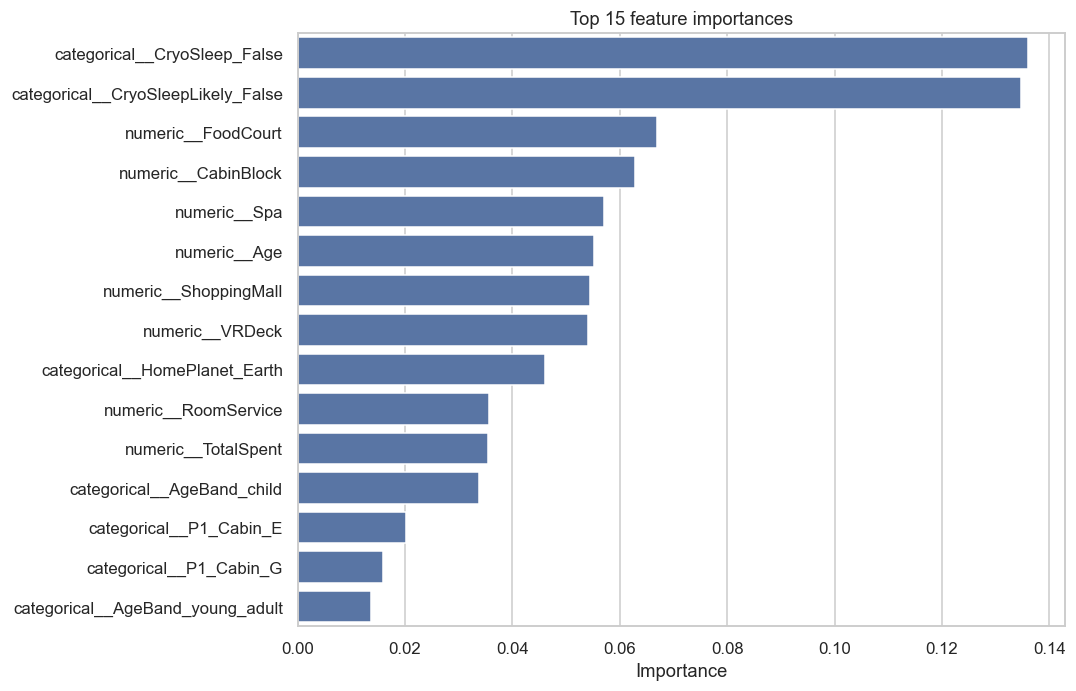

In [570]:
pipeline_3.fit(df_train, y_train)

feature_names = pipeline_3.named_steps['preprocess'].get_feature_names_out()
importance = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': pipeline_3.named_steps['model'].feature_importances_,
    })
    .sort_values('importance', ascending=False)
)
display(importance.head(20))

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=importance.head(15), x='importance', y='feature', ax=ax, color='#4C72B0')
ax.set(title='Top 15 feature importances', xlabel='Importance', ylabel='')
plt.show()

## 10. Test-set preparation and submission

Apply the same cabin parsing, missing-value treatment, categorical representation, and trained model to the held-out competition data. The submission preserves the templates passenger order and writes boolean `Transported` predictions.


In [571]:
df_test_2 = df_test.copy()


In [572]:
df_test_2['GroupID'] = df_test_2['PassengerId'].str.split('_', expand=True).get(0)
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

# CryoSleep = True → fill NaN with 0
df_test_2.loc[df_test_2["CryoSleep"] == True, spend_cols] = (
    df_test_2.loc[df_test_2["CryoSleep"] == True, spend_cols].fillna(0)
)

# CryoSleep = False → fill NaN with the column mean
df_test_2.loc[df_test_2["CryoSleep"] == False, spend_cols] = (
    df_test_2.loc[df_test_2["CryoSleep"] == False, spend_cols]
      .fillna(df_test_2.loc[df_test_2["CryoSleep"] == False, spend_cols].mean())
)
df_test_2["TotalSpent"] = df_test_2[spend_cols].sum(axis=1)

df_test_2.loc[df_test_2['CryoSleep'].isna() & (df_test_2["TotalSpent"] == 0), "CryoSleep"] = True
df_test_2.loc[df_test_2['CryoSleep'].isna() & (df_test_2["TotalSpent"] > 0), "CryoSleep"] = False

df_test_2["Age"] = df_test_2["Age"].fillna(df_test_2["Age"].mean())

df_test_2["HomePlanet"] = (
    df_test_2.groupby("GroupID")["HomePlanet"]
    .transform(lambda x: x.ffill().bfill())
)

df_test_2["Cabin"] = (
    df_test_2.groupby("GroupID")["Cabin"]
    .transform(lambda x: x.ffill().bfill())
)

df_test_2["Destination"] = (
    df_test_2.groupby("GroupID")["Destination"]
    .transform(lambda x: x.ffill().bfill())
)

df_test_2[['P1_Cabin', 'P2_Cabin' , 'P3_Cabin']] = df_test_2['Cabin'].str.split('/', expand=True)


C:\Users\Reza.M\AppData\Local\Temp\ipykernel_5864\488979916.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.ffill().bfill())
C:\Users\Reza.M\AppData\Local\Temp\ipykernel_5864\488979916.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.ffill().bfill())
C:\Users\Reza.M\AppData\Local\Temp\ipykernel_5864\488979916.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to th

In [573]:
df_test_2["P2_Cabin"] = pd.to_numeric(
    df_test_2["P2_Cabin"],
    errors="coerce"
)

df_test_2["CabinBlock"] = pd.cut(
    df_test_2["P2_Cabin"],
    bins=5,
    labels=False
)
df_test_2['CryoSleepLikely'] = np.where(df_test_2['CryoSleep'].notna(), df_test_2['CryoSleep'].astype(str), np.where(df_test_2['TotalSpent'].eq(0), 'likely_true', 'likely_false'))
df_test_2['AgeBand'] = pd.cut(df_test_2['Age'], bins=[-1, 12, 18, 30, 45, 60, np.inf], labels=['child', 'teen', 'young_adult', 'adult', 'middle_age', 'senior'])

df_test_2["CabinSize"] = (
    df_test_2.groupby("Cabin")["Cabin"]
      .transform("count")
).astype(str)

df_test_2 = df_test_2.drop(['PassengerId', 'Name','Cabin','GroupID',"P2_Cabin"], axis=1)

In [574]:

y_pred_test = pipeline.predict(df_test_2)


In [575]:
submission = pd.DataFrame({'PassengerId': df_test['PassengerId'], 'Transported': y_pred_test})
submission["Transported"] = submission["Transported"].map({
    1: True,
    0: False
})

In [576]:
submission.to_csv( DATA_DIR / 'submission.csv', index=False)

In [577]:
#X_train_df = pd.DataFrame(X_train, columns=df_train.columns)
#X_train_df.head()

## 12. Final conclusions

This project shows that transportation is associated with a combination of passenger status, cabin location, demographic information, and onboard spending behaviour. EDA and hypothesis testing establish the evidence behind these signals; feature engineering translates them into model-ready predictors; and model comparison identifies the strongest approach within the original experimental design.

For portfolio use, report the selected models validation accuracy and the corresponding Kaggle score after each run. Any future tuning should preserve the same train/test transformations and be evaluated against this documented baseline.
